# GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [1]:
import os
import tensorflow as tf
import sys
import gc
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

2026-04-28 02:06:31.211484: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 02:06:31.546192: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-28 02:06:31.546250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-28 02:06:31.594416: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-28 02:06:31.705280: I tensorflow/core/platform/cpu_feature_guar

3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
/bin/python3
sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-28 02:06:34.289688: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 02:06:34.581423: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 02:06:34.581510: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

sionna.phy.config.seed = 42 # Set seed for reproducible random number generation

2026-04-28 02:06:35.272647: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 02:06:35.272747: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 02:06:35.272766: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 02:06:35.452857: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-28 02:06:35.452920: I external/local_xla/xla/stream_executor

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten, Embedding
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, LinearInterpolator, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator
from sionna.phy.utils import ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank, split_dim
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder
from sionna.phy.mapping import BinarySource, Mapper, Demapper, Constellation
from sionna.phy.utils.metrics import compute_ber
from sionna.phy.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

# Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [4]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
cdl_model = "C" # CDL model to use
delay_spread = 100e-9 # s
speed = 10.0 # Speed for evaluation and training [m/s]
# Ultra-high coherence channel
# delay_spread = 10e-9  # 10 ns → Bc ≈ 16 MHz
# speed = 0.1  # 0.1 m/s → Tc ≈ 428 ms

# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 15.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz
fft_size = 128 # Number of subcarriers forming the resource grid, including the null-subcarrier and the guard bands
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = True # Null the DC subcarrier
num_guard_carriers = [5, 6] # Number of guard carriers on each side
pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_num_conv_channels = 64 # GAN does not need as many conv channels

############################################
## Training configuration
num_training_iterations = 30000 # Number of training iterations
batch_size = 128 # Training batch size

############################################
## Evaluation configuration
results_filename = "neural_receiver_results" # Location to save the results

In [5]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

2026-04-28 02:06:35.897218: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Subcarrier spacing: 30000.0 Hz
OFDM symbol duration: 3.3333333333333335e-05 s
Pilot pattern: <sionna.phy.ofdm.pilot_pattern.KroneckerPilotPattern object at 0x70d4fd04b8b0>
Pilot spacing in time: every 14 symbols
Pilots per symbol: 232


[<Figure size 640x480 with 2 Axes>]

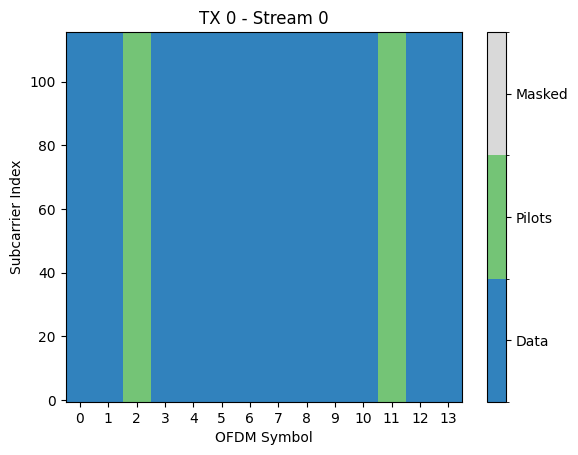

In [6]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                             pilot_pattern = pilot_pattern,
                             pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)
# resource_grid.show()
print(f"Subcarrier spacing: {resource_grid.subcarrier_spacing} Hz")
print(f"OFDM symbol duration: {resource_grid.ofdm_symbol_duration} s")
print(f"Pilot pattern: {resource_grid.pilot_pattern}")
print(f"Pilot spacing in time: every {resource_grid.pilot_pattern.num_ofdm_symbols} symbols")
print(f"Pilots per symbol: {resource_grid.pilot_pattern.num_pilot_symbols}")
resource_grid.pilot_pattern.show()

In [7]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
# data symbols = 1392
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)
print(n)
print(k)

8352
4176


In [8]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

### Resource Grid Util

In [9]:
class ModifiedResourceGridMapper(Layer):
    def __init__(self, resource_grid, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)
        self._data_ind = tf.where(self._rg_type == 0)

        # precompute null subcarrier padding sizes from resource grid
        fft_size = resource_grid.fft_size
        num_active = resource_grid.num_effective_subcarriers
        self._left_guard = resource_grid.num_guard_carriers[0]
        self._right_guard = resource_grid.num_guard_carriers[1]
        self._active_before_dc = fft_size // 2 - self._left_guard
        self._active_after_dc = num_active - self._active_before_dc - 1

    def add_nulled_subcarriers(self, h_hat_active):
        """Fill active subcarriers back into full FFT grid."""
        batch_size = tf.shape(h_hat_active)[0]
        dtype = h_hat_active.dtype

        h_before_dc = h_hat_active[:, :, :self._active_before_dc, :]
        h_after_dc  = h_hat_active[:, :, self._active_before_dc:, :]

        zeros_guard_low  = tf.zeros([batch_size, 14, self._left_guard, 2],  dtype=dtype)
        zeros_dc         = tf.zeros([batch_size, 14, 1, 2],                 dtype=dtype)
        zeros_guard_high = tf.zeros([batch_size, 14, self._right_guard, 2], dtype=dtype)

        return tf.concat([
            zeros_guard_low,
            h_before_dc,
            zeros_dc,
            h_after_dc,
            zeros_guard_high
        ], axis=2)  # concat along subcarrier axis

    def extract_pilots(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        pilot_grid = tf.zeros_like(input_rg)
        pilot_values = tf.gather_nd(input_rg, self._pilot_ind)
        pilot_grid = tf.tensor_scatter_nd_update(pilot_grid, self._pilot_ind, pilot_values)
        return tf.expand_dims(pilot_grid, axis=1)

    def extract_data(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        data_grid = tf.zeros_like(input_rg)
        data_values = tf.gather_nd(input_rg, self._data_ind)
        data_grid = tf.tensor_scatter_nd_update(data_grid, self._data_ind, data_values)
        return tf.expand_dims(data_grid, axis=1)

    def extract_data_symbols_only(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        data_values = tf.gather_nd(input_rg, self._data_ind)
        return tf.expand_dims(data_values, axis=1)

    def replace(self, inputs):
        generated_y_rg, real_y_rg = inputs
        generated_y_rg = tf.squeeze(generated_y_rg, axis=1)
        real_y_rg = tf.squeeze(real_y_rg, axis=1)
        real_pilots = tf.gather_nd(real_y_rg, self._pilot_ind)
        updated_y_rg = tf.tensor_scatter_nd_update(generated_y_rg, self._pilot_ind, real_pilots)
        return tf.expand_dims(updated_y_rg, axis=1)

# resource grid helper
rg_util = ModifiedResourceGridMapper(resource_grid)

## Neural Receiver (NR)

In [10]:
class v1NRResidualBlock(Layer):
    def __init__(self, name=None, **kwargs):
        super(v1NRResidualBlock, self).__init__(name=name, **kwargs)
    
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

class NeuralReceiverV1(Model):
    def __init__(self, **kwargs):
        super(NeuralReceiverV1, self).__init__(**kwargs)
        self.receiver = self.build_receiver()
    
    def build_receiver(self):
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None,
                                 name="neural_receiver_input_conv")
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None,
                                  name="neural_receiver_output_conv")

        # 2*Nt (pilots) + 2*Nr (rx data) + 2*Nr*Nt (channel est)
        # total channels = 2*Nt + 2*Nr + 2*Nr*Nt (real+imag)
        inputs = tf.keras.Input(shape=(14, 128, 2*1 + 2*1 + 2*1*1 +1))
        
        # Input conv
        z = self._input_conv(inputs)
        # Residual blocks
        z = v1NRResidualBlock(name="neural_receiver_residual_block_1")(z)
        z = v1NRResidualBlock(name="neural_receiver_residual_block_2")(z)
        z = v1NRResidualBlock(name="neural_receiver_residual_block_3")(z)
        z = v1NRResidualBlock(name="neural_receiver_residual_block_4")(z)
        # Output conv
        z = self._output_conv(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_receiver")

    def call(self, inputs):
        y, x_p, h_hat, no = inputs # [batch, Nt, Nr, ofdm, fft, 2]
        
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0, 2, 3, 1, 4]) # [batch, ofdm, fft, Nr, 2]
        y_flat = tf.concat([y[..., 0], y[..., 1]], axis=-1)
        
        x_p = tf.squeeze(x_p, axis=2)
        x_p = tf.transpose(x_p, [0, 2, 3, 1, 4]) # [batch, ofdm, fft, Nt, 2]
        x_flat = tf.concat([x_p[..., 0], x_p[..., 1]], axis=-1)
        
        h_hat = tf.transpose(h_hat, [0, 3, 4, 1, 2, 5]) # [batch, ofdm, fft, Nt, Nr, 2]
        h_flat_I = h_hat[..., 0]  # [batch, ofdm, fft, Nt, Nr]
        h_flat_Q = h_hat[..., 1]  # [batch, ofdm, fft, Nt, Nr]
        h_flat_I = tf.reshape(h_flat_I, [tf.shape(h_hat)[0], tf.shape(h_hat)[1], tf.shape(h_hat)[2], -1])  # [batch, ofdm, fft, Nt*Nr]
        h_flat_Q = tf.reshape(h_flat_Q, [tf.shape(h_hat)[0], tf.shape(h_hat)[1], tf.shape(h_hat)[2], -1])  # [batch, ofdm, fft, Nt*Nr]
        h_flat = tf.concat([h_flat_I, h_flat_Q], axis=-1)  # [batch, ofdm, fft, 2*Nt*Nr]

        no = log10(no)
        no = insert_dims(no, 3, 1)                   # [batch, 1, 1, 1]
        no = tf.tile(no, [1, y_flat.shape[1], y_flat.shape[2], 1])  # [batch, ofdm, fft, 1]
        
        # z: [batch, ofdm, fft, 2*Nr+2*Nt+2*Nr*Nt]
        z = tf.concat([y_flat, x_flat, h_flat, no], axis=-1)
        
        z = self.receiver(z)
        
        return z

In [11]:
NR1 = NeuralReceiverV1()

_ = NR1([
    tf.zeros([1, 1, 1, 14, 128, 2]),   # y:     [batch, Nr, Nt, ofdm, fft, 2]
    tf.zeros([1, 1, 1, 14, 128, 2]),   # x_p:   [batch, Nt, Nr, ofdm, fft, 2]
    tf.zeros([1, 1, 1, 14, 128, 2]),   # h_hat: [batch, Nr, Nt, ofdm, fft, 2]
    tf.zeros([1]),                      # no:    [batch]
])

NR1.summary()

2026-04-28 02:06:37.367003: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-28 02:06:37.628428: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Model: "neural_receiver_v1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 neural_receiver_input_conv  (None, 14, 128, 128)      8192      
  (Conv2D)                                                       
                                                                 
 neural_receiver_output_con  (None, 14, 128, 6)        6918      
 v (Conv2D)                                                      
                                                                 
 Neural_receiver (Functiona  (None, 14, 128, 6)        4865798   
 l)                                                              
                                                                 
Total params: 4865798 (18.56 MB)
Trainable params: 4865798 (18.56 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### V2-NR <a class="anchor" id="Neural-Receiver"></a>

In [12]:
class v2NRResidualBlock(Layer):
    def __init__(self, kernel_size=[3,3], **kwargs):
        super().__init__(**kwargs)
        self._kernel_size = kernel_size
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=self._kernel_size,
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=self._kernel_size,
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

In [13]:
class NR_NN1(Model):
    """
        y_pilot, x_pilot, no                      [batch, 2, fft_size], [batch]
            ↓  stack real/imag + tile no          [batch, 2, fft_size, 5]
            ↓  input Conv2D [1,3]  (freq only)
            ↓  ResBlock [1,3]*2                 ← denoise along frequency
                                                  [batch, 2, fft_size, C]
            ↓  Dense(2 → 14) along time axis      ← learned interpolation
                                                  [batch, 14, fft_size, C]
        Output: H_feature

    Input
    -----
    y_pilot : [batch, 2, fft_size], tf.complex64
    x_pilot : [batch, 2, fft_size], tf.complex64
    no      : [batch], tf.float32

    Output
    ------
    H_feature : [batch, 14, fft_size, num_conv_channels], tf.float32
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Input convolution (frequency only, 1x3)
        self._input_conv = Conv2D(filters=num_conv_channels,
                                kernel_size=[1,3],
                                padding='same',
                                activation=None)
        
        # Residual blocks for frequency denoising
        self._res_block_freq_1 = v2NRResidualBlock(kernel_size=[1,3])
        self._res_block_freq_2 = v2NRResidualBlock(kernel_size=[1,3])

        # interpolation from 2 pilot symbols to 14 OFDM symbols
        self._interp_dense = Dense(14, activation=None)

    def call(self, y_pilot, x_pilot, no):
        # y_pilot, x_pilot: [batch, 2, fft_size, 2] — already real (I/Q in last dim)
        # no: [batch]

        no = log10(no)
        no = insert_dims(no, 3, 1)                                    # [batch, 1, 1, 1]
        no = tf.tile(no, [1, y_pilot.shape[1], y_pilot.shape[2], 1]) # [batch, 2, fft_size, 1]

        # y_pilot/x_pilot [batch, 2, fft_size, 2] float32
        z = tf.concat([y_pilot, x_pilot, no], axis=-1)  # [batch, 2, fft_size, 5]

        z = self._input_conv(z)
        z = self._res_block_freq_1(z)
        z = self._res_block_freq_2(z)  # [batch, 2, fft_size, C]

        z = tf.transpose(z, [0, 2, 3, 1])   # [batch, fft_size, C, 2]
        z = self._interp_dense(z)            # [batch, fft_size, C, 14]
        z = tf.transpose(z, [0, 3, 1, 2])   # [batch, 14, fft_size, C]

        return z


class NR_NN2(Model):
    """
    Input
    -----
    H_feature : [batch, 14, fft_size, C],          tf.float32
    no        : [batch, 1],                        tf.float32
    y         : [batch, num_rx_ant, 14, fft_size], tf.complex64
    constellation_points : [M, 2],                 tf.float32

    Output
    ------
    llrs : [batch, 14, fft_size, num_bits_per_symbol], tf.float32
        LLRs at non-data positions discarded.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Input convolution
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None)
        # Residual blocks
        self._res_block_1 = v2NRResidualBlock()
        self._res_block_2 = v2NRResidualBlock()
        self._res_block_3 = v2NRResidualBlock()
        self._res_block_4 = v2NRResidualBlock()
        # Output conv
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None)

    def call(self, H_feature, y, no, constellation_points):
        # y: [batch, num_rx_ant, 14, fft_size, 2]
        no = log10(no)

        # Rearrange and merge antenna + I/Q into channel dim — use static shapes
        num_rx_ant = y.shape[1]   # statically known (=1)
        iq = y.shape[4]            # statically known (=2)
        y = tf.transpose(y, [0, 2, 3, 1, 4])          # [batch, 14, fft_size, rx_ant, 2]
        y = tf.reshape(y, [-1, y.shape[1], y.shape[2], num_rx_ant * iq])  
        # [batch, 14, fft_size, 2]  ← static channel dim

        no = insert_dims(no, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1])  # [batch, 14, fft_size, 1]

        z = tf.concat([y, no, H_feature], axis=-1)
        # [batch, 14, fft_size, 2 + 1 + num_conv_channels]  ← all static

        # constellation_points: [64, 2] → flatten to [128]
        const_flat = tf.reshape(constellation_points, [-1])
        batch_size = tf.shape(z)[0]
        const_tiled = tf.tile(
            tf.reshape(const_flat, [1, 1, 1, -1]),
            [batch_size, z.shape[1], z.shape[2], 1]
        )  # [batch, 14, fft_size, 128]

        z = tf.concat([z, const_tiled], axis=-1)
        # [batch, 14, fft_size, 2 + 1 + C + 128]  ← static ✓

        z = self._input_conv(z)
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        z = self._output_conv(z)

        return z

In [14]:
class NeuralReceiverV2(Model):
    """
    Input
    ------
    y : [batch size, num rx antenna, num ofdm symbols, num subcarriers], tf.complex
        Received post-DFT samples.

    no : [batch size], tf.float32
        Noise variance. At training, a different noise variance value is sampled for each batch example.

    Output
    -------
    : [batch size, num ofdm symbols, num subcarriers, num_bits_per_symbol]
        LLRs on the transmitted bits.
        LLRs computed for resource elements not carrying data (pilots, guard bands...) must be discarded.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._channel_estimation = NR_NN1()
        self._equalization = NR_NN2()

    def call(self, y, no, y_pilot, x_pilot, constellation_points):
        # NN1: Channel estimation and interpolation
        H_feature = self._channel_estimation(y_pilot, x_pilot, no)
        # NN2: Equalization and demapping
        llrs = self._equalization(H_feature, y, no, constellation_points)
        return llrs

In [15]:
NR2 = NeuralReceiverV2()

y_pilot = tf.zeros([1, 2, 128, 2])
x_pilot = tf.zeros([1, 2, 128, 2])
y = tf.zeros([1, 1, 14, 128, 2])
no = tf.zeros([1], dtype=tf.float32)
constellation_points = tf.zeros([64, 2], dtype=tf.float32)

_ = NR2(y, no, y_pilot, x_pilot, constellation_points=constellation_points)
NR2._channel_estimation.summary()
NR2._equalization.summary()

Model: "nr_nn1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           multiple                  2048      
                                                                 
 v2nr_residual_block (v2NRR  multiple                  229632    
 esidualBlock)                                                   
                                                                 
 v2nr_residual_block_1 (v2N  multiple                  229632    
 RResidualBlock)                                                 
                                                                 
 dense (Dense)               multiple                  42        
                                                                 
Total params: 461354 (1.76 MB)
Trainable params: 461354 (1.76 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "nr_nn2"
________

### FiLM-V2-NR

In [112]:
class FiLMResidualBlock(Layer):
    def __init__(self, kernel_size=[3,3], **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels, kernel_size=kernel_size, padding='same', activation=None)
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels, kernel_size=kernel_size, padding='same', activation=None)
        self._film = Dense(2 * num_conv_channels, activation=None)

    def call(self, inputs, cond):
        gamma, beta = tf.split(self._film(cond), 2, axis=-1)
        gamma = insert_dims(gamma, 2, 1)  # [batch, 1, 1, C]
        beta  = insert_dims(beta,  2, 1)

        z = self._layer_norm_1(inputs)
        z = gamma * z + beta
        z = relu(z)
        z = self._conv_1(z)

        z = self._layer_norm_2(z)
        z = gamma * z + beta
        z = relu(z)
        z = self._conv_2(z)

        return z + inputs

class FiLMConditioner(Layer):
    def __init__(self, num_mod_orders=3, **kwargs):
        super().__init__(**kwargs)
        self._mod_embedding = Embedding(num_mod_orders, 16)  # 0=QPSK, 1=16QAM, 2=64QAM

    def call(self, mcs_idx, no_log):
        mod_emb = self._mod_embedding(mcs_idx) # [batch, 16]
        return tf.concat([mod_emb, no_log[:, None]], axis=-1) # [batch, 17]

In [113]:
class FiLM_NR_NN1(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._input_conv = Conv2D(filters=num_conv_channels, kernel_size=[1,3], padding='same', activation=None)
        self._res_block_freq_1 = FiLMResidualBlock(kernel_size=[1,3])
        self._res_block_freq_2 = FiLMResidualBlock(kernel_size=[1,3])
        self._interp_dense = Dense(14, activation=None)

    def call(self, y_pilot, x_pilot, no_log, cond):
        # no_log already log10-scaled
        no = insert_dims(no_log, 3, 1)
        no = tf.tile(no, [1, 2, y_pilot.shape[-1], 1]) # [batch, 2, fft_size, 1]

        z = tf.stack([tf.math.real(y_pilot),
                      tf.math.imag(y_pilot),
                      tf.math.real(x_pilot),
                      tf.math.imag(x_pilot)], axis=-1) # [batch, 2, fft_size, 4]
        z = tf.concat([z, no], axis=-1) # [batch, 2, fft_size, 5]

        z = self._input_conv(z)
        z = self._res_block_freq_1(z, cond)
        z = self._res_block_freq_2(z, cond) # [batch, 2, fft_size, C]

        z = tf.transpose(z, [0, 2, 3, 1]) # [batch, fft_size, C, 2]
        z = self._interp_dense(z)
        z = tf.transpose(z, [0, 3, 1, 2]) # [batch, 14, fft_size, C]
        return z


class FiLM_NR_NN2(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._input_conv = Conv2D(filters=num_conv_channels, kernel_size=[3,3], padding='same', activation=None)
        self._res_block_1 = FiLMResidualBlock()
        self._res_block_2 = FiLMResidualBlock()
        self._res_block_3 = FiLMResidualBlock()
        self._res_block_4 = FiLMResidualBlock()
        self._output_conv = Conv2D(filters=num_bits_per_symbol, kernel_size=[3,3], padding='same', activation=None)

    def call(self, H_feature, y, no_log, cond):
        y = tf.transpose(y, [0, 2, 3, 1]) # [batch, 14, fft_size, rx_ant]

        no = insert_dims(no_log, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1]) # [batch, 14, fft_size, 1]

        z = tf.concat([tf.math.real(y), tf.math.imag(y), no, H_feature], axis=-1)

        z = self._input_conv(z)
        z = self._res_block_1(z, cond)
        z = self._res_block_2(z, cond)
        z = self._res_block_3(z, cond)
        z = self._res_block_4(z, cond)
        z = self._output_conv(z)
        return z


class NeuralReceiver(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._conditioner = FiLMConditioner()
        self._channel_estimation = FiLM_NR_NN1()
        self._equalization = FiLM_NR_NN2()

    def call(self, y, no, y_pilot, x_pilot, mcs_idx):
        no_log = log10(no) # log10 here for easier computation
        cond = self._conditioner(mcs_idx, no_log) # [batch, 17]

        H_feature = self._channel_estimation(y_pilot, x_pilot, no_log, cond)
        llrs = self._equalization(H_feature, y, no_log, cond)
        return llrs

In [114]:
NR = NeuralReceiver()

y_pilot = tf.zeros([1, 2, 128], dtype=tf.complex64)
x_pilot = tf.zeros([1, 2, 128], dtype=tf.complex64)
y = tf.zeros([1, 1, 14, 128], dtype=tf.complex64)
no = tf.ones([1], dtype=tf.float32)
mcs_idx = tf.zeros([1], dtype=tf.int32)

_ = NR(y, no, y_pilot, x_pilot, mcs_idx)

NR._channel_estimation.summary()
NR._equalization.summary()

Model: "fi_lm_nr_nn1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_687 (Conv2D)         multiple                  2048      
                                                                 
 fi_lm_residual_block_18 (F  multiple                  234240    
 iLMResidualBlock)                                               
                                                                 
 fi_lm_residual_block_19 (F  multiple                  234240    
 iLMResidualBlock)                                               
                                                                 
 dense_291 (Dense)           multiple                  42        
                                                                 
Total params: 470570 (1.80 MB)
Trainable params: 470570 (1.80 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "fi_lm_nr_n

## CWGAN-GP

In [16]:
class GANGenerator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANGenerator, self).__init__(**kwargs)
        # projection layers
        self._c_proj_pilots_raw = Dense(GAN_num_conv_channels, activation=None)
        self._c_proj_hhat = Dense(GAN_num_conv_channels, activation=None)
        self._c_proj_yreal = Dense(GAN_num_conv_channels, activation=None)

        self.generator = self.build_generator()

    def build_generator(self):
        x_real_input = tf.keras.layers.Input(shape=(14, 128, 2))
        noise_input = tf.keras.layers.Input(shape=(14, 128, noise_dim))
        c_input = tf.keras.layers.Input(shape=(14, 128, GAN_num_conv_channels))

        x = tf.keras.layers.Concatenate()([x_real_input, noise_input, c_input])
        x = tf.keras.layers.Conv2D(GAN_num_conv_channels, (3, 3), padding='same', use_bias=False)(x)
        x = self._resnet_block(x, GAN_num_conv_channels)
        x = self._resnet_block(x, GAN_num_conv_channels)
        x = self._resnet_block(x, GAN_num_conv_channels)
        x = tf.keras.layers.Conv2D(2, (3, 3), padding='same', use_bias=False)(x)

        return tf.keras.Model(inputs=[x_real_input, noise_input, c_input], outputs=x, name="GANChannel_Generator")

    def _resnet_block(self, x, filters):
        residual = x
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.Add()([x, residual])
        return x

    def call(self, z, x, extra_condition, condition_type=None):
        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0, 2, 3, 1, 4])
        x_flat = tf.concat([x[..., 0], x[..., 1]], axis=-1)  # [batch, 14, 128, 2*Nr]

        if condition_type == 'pilots-raw':
            c = tf.squeeze(extra_condition, axis=1)
            c_flat = self._c_proj_pilots_raw(c)          # [batch, 14, 128, GAN_num_conv_channels]

        elif condition_type == 'hhat':
            c_flat = self._c_proj_hhat(extra_condition)  # [batch, 14, 128, GAN_num_conv_channels]

        elif condition_type == 'yreal':
            c = tf.squeeze(extra_condition, axis=1)
            c = tf.transpose(c, [0, 2, 3, 1, 4])
            c = tf.concat([c[..., 0], c[..., 1]], axis=-1)
            c_flat = self._c_proj_yreal(c)               # [batch, 14, 128, GAN_num_conv_channels]

        else:
            raise ValueError(f"Invalid condition_type '{condition_type}'.")

        y = self.generator([x_flat, z, c_flat])
        y = tf.expand_dims(y, axis=1)
        y = tf.expand_dims(y, axis=2)
        return y, c_flat

In [17]:
gan_generator = GANGenerator()
gan_generator.generator.summary()

Model: "GANChannel_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 14, 128, 100)]       0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 14, 128, 64)]        0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 14, 128, 166)         0         ['input_2[0][0]',             
                                                                     'input_3[0

In [18]:
class GANDiscriminator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANDiscriminator, self).__init__(**kwargs)
        self.discriminator = self.build_discriminator()

    def build_discriminator(self):
        # y_flat: 2, x_flat: 2, c_flat: GAN_num_conv_channels
        y_rg = tf.keras.layers.Input(shape=(14, 128, 2 + 2 + GAN_num_conv_channels))

        y = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same')(y_rg)
        y = tf.keras.layers.LeakyReLU()(y)
        y = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same')(y)
        y = tf.keras.layers.LeakyReLU()(y)
        y = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same')(y)
        y = tf.keras.layers.LeakyReLU()(y)

        y = tf.keras.layers.GlobalAveragePooling2D()(y)
        y = tf.keras.layers.Dense(128)(y)
        D_logit = tf.keras.layers.Dense(1, activation='linear')(y)

        return tf.keras.Model(inputs=y_rg, outputs=D_logit, name="GANChannel_Discriminator")

    def call(self, y, x, c_flat):
        # y, x: [batch, Nt, Nr, 14, 128, 2]
        # c_flat: [batch, 14, 128, GAN_num_conv_channels] — already projected by generator
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0, 2, 3, 1, 4])
        y_flat = tf.concat([y[..., 0], y[..., 1]], axis=-1)  # [batch, 14, 128, 2*Nr]

        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0, 2, 3, 1, 4])
        x_flat = tf.concat([x[..., 0], x[..., 1]], axis=-1)  # [batch, 14, 128, 2*Nr]

        cat = tf.concat([y_flat, x_flat, c_flat], axis=-1)   # [batch, 14, 128, 2+2+GAN_num_conv_channels]

        return self.discriminator(cat)

In [19]:
gan_discriminator = GANDiscriminator()
gan_discriminator.discriminator.summary()

Model: "GANChannel_Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 14, 128, 68)]     0         
                                                                 
 conv2d_31 (Conv2D)          (None, 14, 128, 64)       39232     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 128, 64)       0         
                                                                 
 conv2d_32 (Conv2D)          (None, 14, 128, 128)      73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 14, 128, 128)      0         
                                                                 
 conv2d_33 (Conv2D)          (None, 14, 128, 256)      295168    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 12

### Res-CWGAN-GP

In [20]:
class GANPilotEncoder(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._input_conv = Conv2D(GAN_num_conv_channels, kernel_size=[1,3], padding='same', activation=None)
        self._interp_dense = Dense(14, activation=None)

    def _res_block(self, x, filters):
        residual = x
        x = tf.keras.layers.ReLU()(x)
        x = Conv2D(filters, [1,3], padding='same', activation=None)(x)
        x = tf.keras.layers.ReLU()(x)
        x = Conv2D(filters, [1,3], padding='same', activation=None)(x)
        return x + residual

    def call(self, pilots):
        # pilots: [batch, 2, fft_size, 4]
        z = self._input_conv(pilots) # [batch, 2, fft_size, 64]
        z = self._res_block(z, GAN_num_conv_channels)
        z = self._res_block(z, GAN_num_conv_channels) # [batch, 2, fft_size, 64]
        z = tf.transpose(z, [0, 2, 3, 1]) # [batch, fft_size, 64, 2]
        z = self._interp_dense(z) # [batch, fft_size, 64, 14]
        z = tf.transpose(z, [0, 3, 1, 2]) # [batch, 14, fft_size, 64]
        return z


class ResGANGenerator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(ResGANGenerator, self).__init__(**kwargs)
        self._pilot_encoder = GANPilotEncoder()
        # projection layer
        self._c_proj_pilots_raw = Dense(GAN_num_conv_channels, activation=None)
        self._c_proj_hhat = Dense(GAN_num_conv_channels, activation=None)
        self._c_proj_yreal = Dense(GAN_num_conv_channels, activation=None)

        self.generator = self.build_generator()

    def _resnet_block(self, x, filters):
        residual = x
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters, (3,3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters, (3,3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.Add()([x, residual])
        return x

    def build_generator(self):
        x_real_input = tf.keras.layers.Input(shape=(14,128,2))
        noise_input = tf.keras.layers.Input(shape=(14,128,noise_dim))
        c_input = tf.keras.layers.Input(shape=(14,128,64))

        x = tf.keras.layers.Concatenate()([x_real_input, noise_input, c_input])
        x = tf.keras.layers.Conv2D(GAN_num_conv_channels, (3,3), padding='same', use_bias=False)(x)
        x = self._resnet_block(x, GAN_num_conv_channels)
        x = self._resnet_block(x, GAN_num_conv_channels)
        x = self._resnet_block(x, GAN_num_conv_channels)
        x = tf.keras.layers.Conv2D(2, (3,3), padding='same', use_bias=False)(x)

        return tf.keras.Model(inputs=[x_real_input, noise_input, c_input], outputs=x, name="GANChannel_Generator")

    def call(self, z, x, extra_condition, condition_type=None):
        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0, 2, 3, 1, 4])
        x_flat = tf.concat([x[..., 0], x[..., 1]], axis=-1)  # [batch, 14, 128, 2*Nr]

        if condition_type == 'pilots-raw':
            c = tf.squeeze(extra_condition, axis=1)
            c_flat = self._c_proj_pilots_raw(c)          # [batch, 14, 128, 64]
        
        elif condition_type == 'pilots-ft':
            c_flat = self._pilot_encoder(extra_condition) # [batch, 14, 128, 64]
        
        elif condition_type == 'hhat':
            c_flat = self._c_proj_hhat(extra_condition)   # [batch, 14, 128, 64]
        
        elif condition_type == 'yreal':
            c = tf.squeeze(extra_condition, axis=1)
            c = tf.transpose(c, [0, 2, 3, 1, 4])
            c = tf.concat([c[..., 0], c[..., 1]], axis=-1)
            c_flat = self._c_proj_yreal(c)                # [batch, 14, 128, 64]
        
        else:
            raise ValueError(f"Invalid condition_type '{condition_type}'.")

        y = self.generator([x_flat, z, c_flat])
        y = tf.expand_dims(y, axis=1)
        y = tf.expand_dims(y, axis=2)
        return y, c_flat

In [21]:
res_gan_generator = ResGANGenerator()
res_gan_generator.generator.summary()

Model: "GANChannel_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 input_7 (InputLayer)        [(None, 14, 128, 100)]       0         []                            
                                                                                                  
 input_8 (InputLayer)        [(None, 14, 128, 64)]        0         []                            
                                                                                                  
 concatenate_1 (Concatenate  (None, 14, 128, 166)         0         ['input_6[0][0]',             
 )                                                                   'input_7[0

In [22]:
class ResGANDiscriminator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(ResGANDiscriminator, self).__init__(**kwargs)
        self.discriminator = self.build_discriminator()

    def _resnet_block(self, x, filters):
        residual = x
        x = tf.keras.layers.LeakyReLU()(x)
        x = tf.keras.layers.Conv2D(filters, (3,3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.LeakyReLU()(x)
        x = tf.keras.layers.Conv2D(filters, (3,3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.Add()([x, residual])
        return x

    def build_discriminator(self):
        # 2*Nr + 2*Nr + 64 = 4 + 64 = 68 for Nr=1
        y_rg = tf.keras.layers.Input(shape=(14, 128, 4 + 64))  # adjust 4 if Nr != 1

        y = tf.keras.layers.Conv2D(64, (3,3), padding='same')(y_rg)
        y = self._resnet_block(y, 64)
        y = self._resnet_block(y, 64)
        y = self._resnet_block(y, 64)

        y = tf.keras.layers.GlobalAveragePooling2D()(y)
        y = tf.keras.layers.Dense(128)(y)
        D_logit = tf.keras.layers.Dense(1, activation='linear')(y)

        return tf.keras.Model(inputs=y_rg, outputs=D_logit, name="GANChannel_Discriminator")

    def call(self, y, x, c_flat):
        # c_flat: already interpolated by generator, [batch, 14, 128, 2]
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0, 2, 3, 1, 4])
        y_flat = tf.concat([y[..., 0], y[..., 1]], axis=-1)

        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0, 2, 3, 1, 4])
        x_flat = tf.concat([x[..., 0], x[..., 1]], axis=-1)

        cat = tf.concat([y_flat, x_flat, c_flat], axis=-1)  # [batch, 14, 128, 6]
        return self.discriminator(cat)

In [23]:
gan_discriminator = ResGANDiscriminator()
gan_discriminator.discriminator.summary()

Model: "GANChannel_Discriminator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_9 (InputLayer)        [(None, 14, 128, 68)]        0         []                            
                                                                                                  
 conv2d_43 (Conv2D)          (None, 14, 128, 64)          39232     ['input_9[0][0]']             
                                                                                                  
 leaky_re_lu_3 (LeakyReLU)   (None, 14, 128, 64)          0         ['conv2d_43[0][0]']           
                                                                                                  
 conv2d_44 (Conv2D)          (None, 14, 128, 64)          36864     ['leaky_re_lu_3[0][0]']       
                                                                           

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

### Res-SNR-Mapper

In [83]:
class ResidualBlock1D(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=-1)
        self._dense_1 = Dense(256, activation=None)
        self._layer_norm_2 = LayerNormalization(axis=-1)
        self._dense_2 = Dense(256, activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._dense_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._dense_2(z)
        # Skip connection
        z = z + inputs
        return z

class ResSNRMapper(Layer):
    def __init__(self, num_bits_per_symbol, **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        
        # SNR embedding network with ResNet
        self._input_dense = Dense(256, activation=None, name='snr_input')
        self._res_blocks = [ResidualBlock1D(name=f'res_block_{i}') for i in range(3)]
        self._output_dense_I = Dense(self.num_constellation_points, name='constellation_I')
        self._output_dense_Q = Dense(self.num_constellation_points, name='constellation_Q')
        
        # mapping bit positions
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [..., num_bits] binary tensor
            ebno_db: scalar or [...] - SNR in dB
        """
        batch_size = tf.shape(bits)[0]
        
        # Process SNR through ResNet
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        
        z = self._input_dense(ebno_db_expanded, training=training)
        for res_block in self._res_blocks:
            z = res_block(z)
        
        points_r = self._output_dense_I(z, training=training)  # [batch, M]
        points_i = self._output_dense_Q(z, training=training)  # [batch, M]
        
        # Aggregate to single constellation (non-batched)
        points_r = tf.reduce_mean(points_r, axis=0)  # [M]
        points_i = tf.reduce_mean(points_i, axis=0)  # [M]
        
        # Normalize to unit average energy
        point_energy = points_r**2 + points_i**2
        avg_energy = tf.reduce_mean(point_energy)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor
        
        # Convert bits to indices
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Map bits to constellation (non-batched, so axis=0)
        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)
        
        constellation_points = tf.complex(points_r, points_i)
        
        x_real = tf.stack([x_I, x_Q], axis=-1)
        
        return x_real, constellation_points

### FiLM-Res-SNR-Mapper

In [25]:
class ResidualBlock1D(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=-1)
        self._dense_1 = Dense(256, activation=None)
        self._layer_norm_2 = LayerNormalization(axis=-1)
        self._dense_2 = Dense(256, activation=None)
        self._film = Dense(2 * 256, activation=None)

    def call(self, inputs, cond):
        gamma, beta = tf.split(self._film(cond), 2, axis=-1)  # [batch, 256] each

        z = self._layer_norm_1(inputs)
        z = gamma * z + beta
        z = relu(z)
        z = self._dense_1(z)

        z = self._layer_norm_2(z)
        z = gamma * z + beta
        z = relu(z)
        z = self._dense_2(z)

        return z + inputs


class ResSNRFiLMMapper(Layer):
    def __init__(self, max_bits_per_symbol=6, num_mod_orders=3, **kwargs):
        """
        max_bits_per_symbol: largest M used (e.g. 6 for 64QAM)
        num_mod_orders:      number of modulation orders (e.g. 3 for QPSK/16QAM/64QAM)
        """
        super().__init__(**kwargs)
        self.max_bits_per_symbol = max_bits_per_symbol
        self.max_constellation_points = 2 ** max_bits_per_symbol # 6=64

        # conditioning: mod order embedding + SNR
        self._mod_embedding = Embedding(num_mod_orders, 16)  # 0=QPSK, 1=16QAM, 2=64QAM
        self._cond_dense = Dense(256, activation=None, name='cond_input')

        # ResNet trunk
        self._input_dense = Dense(256, activation=None, name='snr_input')
        self._res_blocks = [ResidualBlock1D(name=f'res_block_{i}') for i in range(3)]

        self._output_dense_I = Dense(self.max_constellation_points, name='constellation_I')
        self._output_dense_Q = Dense(self.max_constellation_points, name='constellation_Q')

    def call(self, bits, ebno_db, mcs_idx, num_bits_per_symbol, training=False):
        """
        Args:
            bits:                [..., num_bits] binary tensor
            ebno_db:             [batch] or scalar
            mcs_idx:             [batch] int - 0=QPSK, 1=16QAM, 2=64QAM
            num_bits_per_symbol: scalar int - actual M for this batch
        """
        batch_size = tf.shape(bits)[0]
        num_constellation_points = 2 ** num_bits_per_symbol

        # prepare conditioning
        ebno = tf.reshape(tf.cast(ebno_db, tf.float32), [batch_size, 1])
        mod_emb = self._mod_embedding(mcs_idx) # [batch, 16]
        cond_raw = tf.concat([ebno, mod_emb], axis=-1) # [batch, 17]
        cond = self._cond_dense(cond_raw) # [batch, 256]

        z = self._input_dense(ebno, training=training) # input SNR
        for res_block in self._res_blocks:
            z = res_block(z, cond) # FiLM conditioning

        points_r = self._output_dense_I(z, training=training) # [batch, 64]
        points_i = self._output_dense_Q(z, training=training) # [batch, 64]

        # slice to actual constellation size
        points_r = points_r[:, :num_constellation_points] # [batch, M]
        points_i = points_i[:, :num_constellation_points] # [batch, M]

        # normalize
        points_r = tf.reduce_mean(points_r, axis=0) # [M]
        points_i = tf.reduce_mean(points_i, axis=0) # [M]
        avg_energy = tf.reduce_mean(points_r**2 + points_i**2)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor

        bit_positions = tf.cast(tf.range(num_bits_per_symbol - 1, -1, -1), dtype=tf.int32)
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / num_bits_per_symbol)
        bits = split_dim(bits, [n1, num_bits_per_symbol], axis=tf.rank(bits) - 1)
        int_rep = tf.reduce_sum(tf.bitwise.left_shift(bits, bit_positions), axis=-1)

        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)

        constellation_points = tf.complex(points_r, points_i)
        x_real = tf.stack([x_I, x_Q], axis=-1)

        return x_real, constellation_points

### MLP-SNR-Mapper

In [84]:
class MlpSNRMapper(Layer):
    def __init__(self,
                 num_bits_per_symbol,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        
        # Base QAM constellation
        qam_points = Constellation("qam", num_bits_per_symbol).points
        
        # Trainable base constellation using tf.Variable
        self.base_points_r = tf.Variable(
            initial_value=tf.math.real(qam_points),
            trainable=True,
            dtype=tf.float32,
            name='base_points_r'
        )
        self.base_points_i = tf.Variable(
            initial_value=tf.math.imag(qam_points),
            trainable=True,
            dtype=tf.float32,
            name='base_points_i'
        )
        
        # SNR embedding network (generates constellation adjustments)
        self.snr_dense1 = Dense(256, activation='relu', name='snr_embed1')
        self.constellation_I_dense = Dense(self.num_constellation_points, name='constellation_I')
        self.constellation_Q_dense = Dense(self.num_constellation_points, name='constellation_Q')
        
        # Bit positions for mapping
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [..., num_bits] binary tensor
            ebno_db: scalar or [...] - SNR in dB
        """
        batch_size = tf.shape(bits)[0]
        
        # Process SNR through embedding network
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        
        x = self.snr_dense1(ebno_db_expanded, training=training)
        
        points_r = self.constellation_I_dense(x, training=training)  # [batch, M]
        points_i = self.constellation_Q_dense(x, training=training)  # [batch, M]
        
        # Aggregate to single constellation (non-batched)
        points_r = tf.reduce_mean(points_r, axis=0)  # [M]
        points_i = tf.reduce_mean(points_i, axis=0)  # [M]
        
        # Normalize to unit average energy
        point_energy = points_r**2 + points_i**2
        avg_energy = tf.reduce_mean(point_energy)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor
        
        # Convert bits to indices
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Map bits to constellation (non-batched, so axis=0)
        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)
        
        constellation_points = tf.complex(points_r, points_i)  # for checking
        
        x_real = tf.stack([x_I, x_Q], axis=-1)
        
        return x_real, constellation_points

### SLP-NoSNR-Mapper

In [85]:
class SlpNoSNRMapper(sionna.phy.Block): 
    def __init__(self,
                 constellation_type=None,
                 num_bits_per_symbol=None,
                 constellation=None,
                 return_indices=False,
                 precision=None,
                 **kwargs
                ):
        super().__init__(precision=precision, **kwargs)
        self._constellation = Constellation.check_or_create(
                                constellation_type=constellation_type,
                                num_bits_per_symbol=num_bits_per_symbol,
                                constellation=constellation,
                                precision=precision)
        self._return_indices = return_indices
        n = self.constellation.num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)

    @property
    def constellation(self):
        return self._constellation
    
    def call(self, bits):
        """
        Args:
            bits: [..., num_bits] binary tensor
        """
        bits = tf.cast(bits, dtype=tf.int32)

        # Reshape last dimensions to the desired format
        n1 = int(bits.shape[-1]/self.constellation.num_bits_per_symbol)
        new_shape = [n1 , self.constellation.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)

        # Use bitwise left shift to compute powers of two
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        # Compute the integer representation using bitwise operations
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Lookup I and Q from trainable constellation
        x_I = tf.gather(tf.math.real(self._constellation()), int_rep, axis=0)
        x_Q = tf.gather(tf.math.imag(self._constellation()), int_rep, axis=0)
        
        x = tf.stack([x_I, x_Q], axis=-1)
        
        return x

### Wrapper

In [28]:
class OFDMChannelReal(Layer):
    def __init__(self, channel_model, resource_grid, 
                 normalize_channel=False, return_channel=False, **kwargs):
        super().__init__(**kwargs)
        
        self._cir_sampler = channel_model
        self._rg = resource_grid
        self._normalize_channel = normalize_channel
        self._return_channel = return_channel
        
        self._generate_channel = GenerateOFDMChannel(
            self._cir_sampler, self._rg, self._normalize_channel
        )
    
    def call(self, x_real, no=None):
        """
        Args:
            x_real: [batch, 1, 1, 14, 128, 2] where last dim is [I, Q]
            no: noise variance (real)
        Returns:
            y_real: [batch, 1, 1, 14, 128, 2] real received signal
            h_real: [batch, 1, 1, 1, 1, 14, 128, 2] real channel (optional)
        """
        batch_size = tf.shape(x_real)[0]
        # Complex channel from Sionna
        h_freq_complex = self._generate_channel(batch_size)  # [batch, 1, 1, num_rx, num_tx, ofdm_syms, subcarriers]
        
        # Convert channel to real representation
        h_real_part = tf.math.real(h_freq_complex)  # [batch, 1, 1, 1, 1, 14, 128]
        h_imag_part = tf.math.imag(h_freq_complex)
        
        # Split x_real into I and Q
        x_I = x_real[..., 0]  # [batch, 1, 1, 14, 128]
        x_Q = x_real[..., 1]  # [batch, 1, 1, 14, 128]
        
        # Squeeze channel dimensions for broadcasting
        h_real = tf.squeeze(h_real_part, axis=[3, 4])  # [batch, 1, 1, 14, 128]
        h_imag = tf.squeeze(h_imag_part, axis=[3, 4])
        
        # Apply complex multiplication as real: (a+bi)(c+di) = (ac-bd) + (ad+bc)i
        y_I = h_real * x_I - h_imag * x_Q
        y_Q = h_imag * x_I + h_real * x_Q
        
        # Add noise
        if no is not None:
            # AWGN: split noise power equally between I and Q
            no = tf.reshape(no, [-1, 1, 1, 1, 1])
            noise_I = tf.random.normal(tf.shape(y_I), stddev=tf.sqrt(no/2))
            noise_Q = tf.random.normal(tf.shape(y_Q), stddev=tf.sqrt(no/2))
            y_I = y_I + noise_I
            y_Q = y_Q + noise_Q
        
        # Stack I and Q in last dimension
        y_real = tf.stack([y_I, y_Q], axis=-1)  # [batch, 1, 1, 14, 128, 2]
        
        if self._return_channel:
            # Stack channel I and Q
            h_real_out = tf.stack([h_real, h_imag], axis=-1)  # [batch, 1, 1, 14, 128, 2]
            h_real_out = tf.expand_dims(h_real_out, axis=3)  # [batch, 1, 1, 1, 1, 14, 128, 2]
            h_real_out = tf.expand_dims(h_real_out, axis=4)  # [batch, 1, 1, 1, 1, 14, 128, 2]
            
            return y_real, h_real_out
        else:
            return y_real

### LS-Hest & LMMSE-Int

In [29]:
n_sample = int(resource_grid.num_data_symbols*num_bits_per_symbol)

def sample_channel(batch_size, snr_db):
    # Create OFDM resource grid
    binary_source = BinarySource()
    rg_mapper = ResourceGridMapper(resource_grid)
    mapper = Mapper("qam", num_bits_per_symbol)
    c = binary_source([batch_size, 1, resource_grid.num_streams_per_tx, n_sample])
    x = mapper(c)
    x_rg = rg_mapper(x)  # OFDM modulated symbols

    ## CDL Channel
    cdl = CDL(cdl_model, delay_spread, carrier_frequency,
              ut_antenna, bs_array, "uplink", min_speed=speed)
    # rayleigh = RayleighBlockFading(num_rx=1, num_rx_ant=2, num_tx=1, num_tx_ant=1)
    channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

    # noise
    ebno_db = tf.constant(10.0, tf.float32)
    no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
    no_ = expand_to_rank(no, tf.rank(x_rg))

    y, H = channel([x_rg, no_])
    
    return y, H, x, x_rg, no_


In [30]:
FFT_SIZE = 128
NUM_OFDM_SYMBOLS = 14
NUM_RX_ANT = 1

def estimate_covariance_matrices(num_it, batch_size):
    # Initialize accumulators
    freq_cov_mat = tf.zeros([FFT_SIZE, FFT_SIZE], tf.complex64)
    time_cov_mat = tf.zeros([NUM_OFDM_SYMBOLS, NUM_OFDM_SYMBOLS], tf.complex64)
    space_cov_mat = tf.ones([NUM_RX_ANT, NUM_RX_ANT], tf.complex64)  # Identity for SISO
    
    total_samples = 0
    
    for i in range(num_it):
        y, h_freq, x_real, x_rg, no_ = sample_channel(batch_size, 10)  # Use a moderate SNR
        
        # Process each sample individually to avoid OOM
        for b in range(batch_size):
            # Extract single channel realization [14, 128]
            h_sample = h_freq[b, 0, 0, 0, 0, :, :]
            
            # For frequency covariance - transpose to get [128, 14]
            h_freq_view = tf.transpose(h_sample)
            # Compute outer product for frequency covariance
            freq_cov_update = tf.matmul(h_freq_view, h_freq_view, adjoint_b=True)
            
            # For time covariance - use [14, 128]
            time_cov_update = tf.matmul(h_sample, h_sample, adjoint_b=True)
            
            # Update accumulators
            freq_cov_mat += freq_cov_update
            time_cov_mat += time_cov_update
            total_samples += 1
    
    # Normalize by total number of samples
    freq_cov_mat /= tf.cast(total_samples, tf.complex64)
    time_cov_mat /= tf.cast(total_samples, tf.complex64)
    
    # Check if values are reasonable (add this for debugging)
    print("Frequency covariance diagonal mean:", 
          tf.reduce_mean(tf.linalg.diag_part(tf.abs(freq_cov_mat))))
    print("Frequency covariance off-diagonal mean:", 
          tf.reduce_mean(tf.abs(freq_cov_mat)) - 
          tf.reduce_mean(tf.linalg.diag_part(tf.abs(freq_cov_mat))))
    
    return freq_cov_mat, time_cov_mat, space_cov_mat

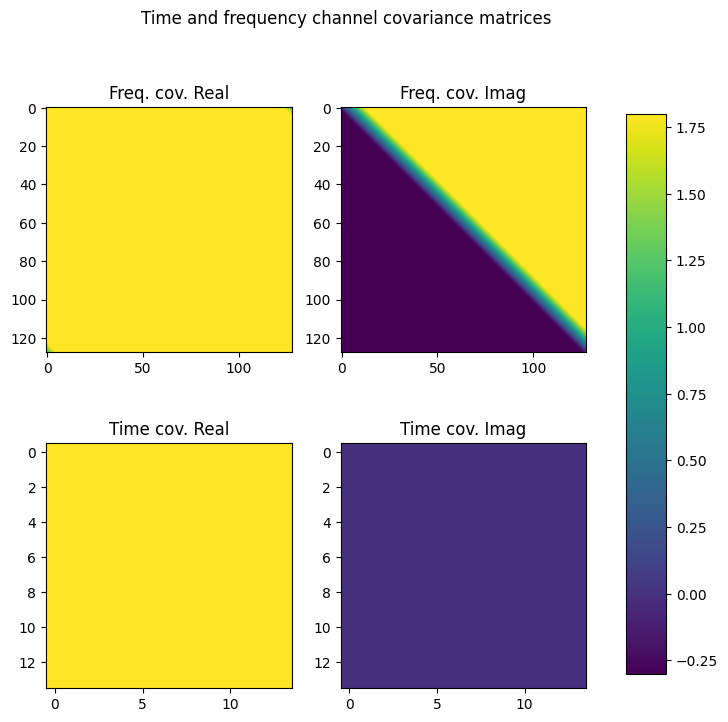

In [31]:
FREQ_COV_MAT = np.load('freq_cov_mat.npy')
TIME_COV_MAT = np.load('time_cov_mat.npy')
SPACE_COV_MAT = np.load('space_cov_mat.npy')

fig, ax = plt.subplots(2,2, figsize=(8,8))
fig.suptitle("Time and frequency channel covariance matrices")

ax[0,0].set_title("Freq. cov. Real")
im = ax[0,0].imshow(FREQ_COV_MAT.real, vmin=-0.3, vmax=1.8)
ax[0,1].set_title("Freq. cov. Imag")
im = ax[0,1].imshow(FREQ_COV_MAT.imag, vmin=-0.3, vmax=1.8)

ax[1,0].set_title("Time cov. Real")
im = ax[1,0].imshow(TIME_COV_MAT.real, vmin=-0.3, vmax=1.8)
ax[1,1].set_title("Time cov. Imag")
im = ax[1,1].imshow(TIME_COV_MAT.imag, vmin=-0.3, vmax=1.8)

# ax[2,0].set_title("Space cov. Real")
# im = ax[2,0].imshow(SPACE_COV_MAT.real, vmin=-0.3, vmax=1.8)
# ax[2,1].set_title("Space cov. Imag")
# im = ax[2,1].imshow(SPACE_COV_MAT.imag, vmin=-0.3, vmax=1.8)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax);


In [32]:
FREQ_COV_MAT = np.load('freq_cov_mat.npy')
TIME_COV_MAT = np.load('time_cov_mat.npy')
SPACE_COV_MAT = np.load('space_cov_mat.npy')
freq_cov_mat = tf.constant(FREQ_COV_MAT, tf.complex64)
time_cov_mat = tf.constant(TIME_COV_MAT, tf.complex64)

active_mask = tf.concat([
   tf.zeros(num_guard_carriers[0], dtype=tf.bool),
   tf.ones(fft_size - num_guard_carriers[0] - num_guard_carriers[1] - 1, dtype=tf.bool),
   tf.zeros(1, dtype=tf.bool),  # DC
   tf.ones(0, dtype=tf.bool) if num_guard_carriers[1] == 0 else tf.zeros(num_guard_carriers[1], dtype=tf.bool)
], axis=0)

active_indices = tf.where(active_mask)[:, 0]
freq_cov_mat = tf.gather(tf.gather(freq_cov_mat, active_indices, axis=0), active_indices, axis=1)
print(freq_cov_mat.shape, time_cov_mat.shape)  # Should be (116, 116), (14, 14)
# Use the processed matrix
lmmse_int_freq_first = LMMSEInterpolator(resource_grid.pilot_pattern, 
                                         time_cov_mat, 
                                         freq_cov_mat, 
                                         order='t-f')
channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

(116, 116) (14, 14)


In [33]:
class RawChannelEstimator(Layer):
    """
    Real-domain raw channel estimates H_raw = Y ⊙ X_p* only at pilot positions
    """
    def __init__(self, resource_grid, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots
        
    def call(self, inputs):
        """
        Args:
            inputs: [y_rg, x_rg]
                y_rg: [batch, num_rx, num_rx_ant, ofdm, fft, 2] where last dim is [I, Q]
                x_rg: [batch, num_tx, num_tx_stream, ofdm, fft, 2] where last dim is [I, Q]
        Returns:
            h_raw: [batch, num_rx, num_rx_ant, ofdm, fft, 2] 
                   sparse raw channel estimates with values only at pilot positions
        """
        y_rg, x_rg = inputs
        
        # Initialize zeros (same shape as y_rg)
        h_raw = tf.zeros_like(y_rg, dtype=self.dtype)
        
        y_squeezed = tf.squeeze(y_rg, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        x_squeezed = tf.squeeze(x_rg, axis=1)  # [batch, num_tx_stream, ofdm, fft, 2]
        
        # Extract pilots using the indices (indices only cover first 4 dims, not I/Q)
        y_pilots = tf.gather_nd(y_squeezed, self._pilot_ind)  # [batch, num_pilots, 2]
        x_pilots = tf.gather_nd(x_squeezed, self._pilot_ind)  # [batch, num_pilots, 2]
        
        # Split into I and Q
        y_I = y_pilots[..., 0]  # [batch, num_pilots]
        y_Q = y_pilots[..., 1]
        x_I = x_pilots[..., 0]
        x_Q = x_pilots[..., 1]
        
        # Compute H_raw = Y ⊙ X_p* in real domain: (a+bi)(c-di) = (ac+bd) + (bc-ad)i
        h_raw_I = y_I * x_I + y_Q * x_Q
        h_raw_Q = y_Q * x_I - y_I * x_Q 
        h_raw_pilots = tf.stack([h_raw_I, h_raw_Q], axis=-1) # [batch, num_pilots, 2]
        
        h_raw_squeezed = tf.squeeze(h_raw, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        h_raw_updated = tf.tensor_scatter_nd_update(
            h_raw_squeezed, 
            self._pilot_ind, 
            h_raw_pilots
        )
        
        h_raw = tf.expand_dims(h_raw_updated, axis=1)  # [batch, num_rx, num_rx_ant, ofdm, fft, 2]
        
        return h_raw  

Raw_channel_estimator = RawChannelEstimator(resource_grid)

### Test Definition

In [34]:
## Transmitter
binary_source = BinarySource()

# QAM mapper baseline
# mapper = Mapper("qam", num_bits_per_symbol)
# rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
# channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

mapper = SlpNoSNRMapper("qam", num_bits_per_symbol)
rg_mapper = ResourceGridMapper(resource_grid)  # This should work
channel = OFDMChannelReal(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiverV1()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements


In [35]:
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
z = tf.random.normal(shape=(batch_size, 1, 14, 128))

## Transmitter
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

# Map bits to QAM symbols
x = mapper(c)
print("x shape: ", x.shape, x.dtype)

# Map the QAM symbols to a resource grid
x = tf.complex(x[...,0], x[...,1])
x_rg = rg_mapper(x)
x_rg = tf.stack([tf.math.real(x_rg), tf.math.imag(x_rg)], axis=-1)
print("x_rg shape: ", x_rg.shape, x_rg.dtype)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
print("no shape: ", no.shape, no_.dtype)
y,h = channel(x_rg, no_)
print("y shape: ", y.shape, y.dtype)
y_p = rg_util.extract_pilots(y)
x_p = rg_util.extract_pilots(x_rg)
print("y_p shape: ", y_p.shape, y_p.dtype)
print("x_p shape: ", x_p.shape, x_p.dtype)

# channel estimation
y_complex = tf.complex(y[..., 0], y[..., 1])
h_hat, _ = channel_estimator(y_complex, no_) # (128, 1, 1, 1, 1, 14, 128)
h_hat = h_hat[:,0,0,0,0,:,:] # (128, 1, 1, 14, 128, 2)
h_hat = tf.stack([tf.math.real(h_hat), tf.math.imag(h_hat)], axis=-1) # (batch, 14, active_sc, 2)
h_hat = rg_util.add_nulled_subcarriers(h_hat)
print("h_hat shape: ", h_hat.shape, h_hat.dtype)

h_raw = Raw_channel_estimator([y, x_rg])
print("h_raw shape: ", h_raw.shape, h_raw.dtype)

######################################
## Receiver
# The neural receover computes LLRs from the frequency domain received symbols and N0
llr = neural_receiver([y, x_p, h_raw, no])
print("llr shape: ", llr.shape, llr.dtype)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr) # 1392 from 1792 (14*128)
print("LLRs before reshape: ", llr.shape, llr.dtype)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape, llr.dtype)

# h_hat = RemoveNulledSubcarriers(resource_grid)(h) # Extract non-null subcarriers
# print("h_hat_perfect shape: ", h_hat.shape)
# x_hat, no_eff = LMMSEEqualizer(resource_grid, stream_manager, )(y, h_hat, 0.0, no) # LMMSE equalization
# no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
# print("x_hat: ", x_hat.shape)
# llr = Demapper("app", "qam", num_bits_per_symbol)(x_hat, no_eff_) # Demapping
# print("LLRs: ", llr.shape)

# h_hat, err_var = LSChannelEstimator(resource_grid, interpolation_type="nn")(y, no) # LS channel estimation with nearest-neighbor
# print("h_hat_LS shape: ", h_hat.shape)
# x_hat, no_eff = LMMSEEqualizer(resource_grid, stream_manager, )(y, h_hat, err_var, no) # LMMSE equalization
# no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
# print("x_hat: ", x_hat.shape)
# llr = Demapper("app", "qam", num_bits_per_symbol)(x_hat, no_eff_) # Demapping
# print("LLRs: ", llr.shape)

c shape:  (128, 1, 1, 8352)
x shape:  (128, 1, 1, 1392, 2) <dtype: 'float32'>
x_rg shape:  (128, 1, 1, 14, 128, 2) <dtype: 'float32'>
no shape:  (128,) <dtype: 'float32'>
y shape:  (128, 1, 1, 14, 128, 2) <dtype: 'float32'>
y_p shape:  (128, 1, 1, 14, 128, 2) <dtype: 'float32'>
x_p shape:  (128, 1, 1, 14, 128, 2) <dtype: 'float32'>
h_hat shape:  (128, 14, 128, 2) <dtype: 'float32'>
h_raw shape:  (128, 1, 1, 14, 128, 2) <dtype: 'float32'>
llr shape:  (128, 14, 128, 6) <dtype: 'float32'>
LLRs before reshape:  (128, 1, 1, 1392, 6) <dtype: 'float32'>
Post RG-demapper LLRs:  (128, 1, 1, 8352) <dtype: 'float32'>


In [36]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: -3.83E-01 bit


# End-to-end System as a Keras Model <a class="anchor" id="End-to-end-System-as-a-Keras-Model"></a>

In [66]:
class E2ESystem(Model):
    def __init__(self, system, training=False, use_fec=True):
        super().__init__()
        self._system = system
        self._training = training
        self._use_fec = use_fec
        self.y_gen = None
        self.y_real = None
        self.raw_channel_estimator = RawChannelEstimator(resource_grid)
        self.channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        if not training and use_fec:
            self._encoder = LDPC5GEncoder(k, n)
        
        if "qamMapper" in system:
            # QAM
            self._mapper = Mapper("qam", num_bits_per_symbol)
            
        elif "slpNoSNRMapper" in system:
            # SLP-NoSNR
            qam_points = Constellation("qam", num_bits_per_symbol).points
            self.constellation = Constellation("custom",
                                        num_bits_per_symbol,
                                        points=qam_points,
                                        normalize=True,
                                        center=True)
            self.points_r = self.add_weight(shape=qam_points.shape,
                                            initializer="zeros")
            self.points_i = self.add_weight(shape=qam_points.shape,
                                            initializer="zeros")
            self.points_r.assign(tf.math.real(qam_points))
            self.points_i.assign(tf.math.imag(qam_points))

            self._mapper = SlpNoSNRMapper(constellation=self.constellation) 

        elif "mlpSNRMapper" in system:
            # MLP-SNR
            self._mapper = MlpSNRMapper(num_bits_per_symbol=num_bits_per_symbol)
        elif "resSNRMapper" in system:
            # Res-SNR
            self._mapper = ResSNRMapper(num_bits_per_symbol=num_bits_per_symbol)

        self._rg_mapper = ResourceGridMapper(resource_grid)

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannelReal(cdl, resource_grid, normalize_channel=True, return_channel=True)

        if "GAN" in system:
            if "GAN-v1" in self._system:
                self._gan_channel = GANGenerator()
            elif "GAN-v2" in system:
                self._gan_channel = ResGANGenerator()

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of `system`
        if "baseline" in system:
            self._removed_null_subc = RemoveNulledSubcarriers(resource_grid)
            self.interpolator = LinearInterpolator(resource_grid.pilot_pattern)
            self._ls_est = LSChannelEstimator(resource_grid, interpolator=self.interpolator)
            # Components required by both baselines
            self._lmmse_equ = LMMSEEqualizer(resource_grid, stream_manager, )
            self._demapper = Demapper("app", "qam", num_bits_per_symbol)
        elif "neural-receiver" in system: # Neural receiver
            if "neural-receiver-v1" in self._system: 
                self._neural_receiver = NeuralReceiverV1()
            elif "neural-receiver-v2" in self._system:
                self._neural_receiver = NeuralReceiverV2()
            self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements
        else:
            print("Invalid system!")
        
        if not training and use_fec:
            self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)

    # @tf.function
    def call(self, batch_size, ebno_db, use_gan_channel=False):
        
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db) # n0 = es / (eb/n0 x num_bits x coderate) lower R -> higher noise power

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n]) # u=4176*2
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k]) # k=4176
            c = self._encoder(b) # u=n=4176*2
        
        # Modulation
        if "qamMapper" in self._system:
            x = self._mapper(c)
            constellation_points = self._mapper.constellation.points

        elif "slpNoSNRMapper" in self._system:
            constellation_points = tf.complex(self.points_r, self.points_i)
            self.constellation.points = constellation_points
            x = self._mapper(c) # [batch, num_symbols, 2]

        elif "mlpSNRMapper" in self._system:
            x, constellation_points = self._mapper(c, ebno_db, training=self._training)

        elif "resSNRMapper" in self._system:
            x, constellation_points = self._mapper(c, ebno_db, training=self._training)
        
        self.constellation_points = constellation_points
        # complex constellation points to be put in NNRx
        constellation_points = tf.stack([tf.math.real(constellation_points),
                            tf.math.imag(constellation_points)], axis=-1)

        x = tf.complex(x[...,0], x[...,1])
        x_rg = self._rg_mapper(x)
        x_rg = tf.stack([tf.math.real(x_rg), tf.math.imag(x_rg)], axis=-1) # [batch, 1, 1, 14, 128, 2]

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._real_channel(x_rg, no_) # [batch, 1, 1, 14, 128, 2]
        y_complex = tf.complex(y[..., 0], y[..., 1])

        h_freq = h[:,0,0,0,0,:,:,:] # [batch, 14, 128, 2]
        self.y_real = y
        
        # channel estimation
        h_hat = self.raw_channel_estimator([self.y_real, x_rg])  # [batch, 1, 1, 14, 128, 2]
        
        # extract pilot symbols from received signal and transmitted pilots
        y_pilot = tf.gather(y[:, 0, 0, :, :], pilot_ofdm_symbol_indices, axis=1)  # [batch, 2, fft, 2]
        x_pilot = tf.gather(x_rg[:, 0, 0, :, :], pilot_ofdm_symbol_indices, axis=1)  # [batch, 2, fft, 2]
        
        # this is pilot grid (with padded 0)
        y_pilot_grid = rg_util.extract_pilots(y)    # [batch, 1, 14, 128, 2]
        x_pilot_grid = rg_util.extract_pilots(x_rg) # [batch, 1, 14, 128, 2]
        
        ### ----------------- GAN channel
        if use_gan_channel: 
            h_hat_lmmse, _ = self.channel_estimator(y_complex, no_) # (batch, 1, 1, 1, 1, 14, active_sc)
            h_hat_lmmse = h_hat_lmmse[:,0,0,0,0,:,:] # (batch, 14, active_sc) 
            h_hat_lmmse = tf.stack([tf.math.real(h_hat_lmmse), tf.math.imag(h_hat_lmmse)], axis=-1) # (batch, 14, active_sc, 2)
            h_hat_lmmse = rg_util.add_nulled_subcarriers(h_hat_lmmse)    # (batch, 14, fft_size, 2)

            z = tf.random.normal([batch_size, 14, 128, noise_dim])
            
            pilots = tf.concat([y_pilot, x_pilot], axis=-1) # (batch, 2, fft, 4)
            # pilots = tf.concat([y_pilot_grid, x_pilot_grid], axis=-1)  # [batch, 1, 14, 128, 4]
            # pilots = tf.squeeze(pilots, axis=1)

            y, _ = self._gan_channel(z, x_rg, self.y_real, condition_type='yreal')
            # y, _ = self._gan_channel(z, x_rg, pilots, condition_type='pilots-ft')
            # y, _ = self._gan_channel(z, x_rg, pilots, condition_type='pilots-raw')
            # y, _ = self._gan_channel(z, x_rg, h_freq, condition_type='hhat')
            
            self.y_gen = y
        
        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of ``system``
        if "baseline" in self._system:
            if 'baseline-perfect-csi' in self._system:
                h_complex = tf.complex(h[..., 0], h[..., 1])  # [batch, 1, 1, 14, 128]
                h_hat = self._removed_null_subc(h_complex) # Extract non-null subcarriers
                err_var = 0.0 # No channel estimation error when perfect CSI knowledge is assumed
            elif 'baseline-ls-estimation' in self._system:
                h_hat, err_var = self._ls_est(y_complex, no) # LS channel estimation with nearest-neighbor
                err_var = 0.0
                
            x_hat, no_eff = self._lmmse_equ(y_complex, h_hat, err_var, no) # LMMSE equalization
            no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
            llr = self._demapper(x_hat, no_eff_) # Demapping

        elif "neural-receiver" in self._system:
            if "neural-receiver-v1" in self._system:  
                # The neural receover computes LLRs from the frequency domain received symbols and N0
                llr = self._neural_receiver([y, x_pilot_grid, h_hat, no])
                llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
                llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
                llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected
                
            elif "neural-receiver-v2" in self._system:
                # The neural receiver computes LLRs from the frequency domain received symbols and N0
                y = tf.squeeze(y, axis=2)  # [batch, 1, 14, fft_size] - keep num_rx_ant dim
                llr = self._neural_receiver(y, no, y_pilot, x_pilot, constellation_points)
                llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
                llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
                llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected
            else:
                print("Invalid Neural Receiver!")
        
        # Outer coding is not needed if the information rate is returned
        if self._training:
            # Compute and return BMD rate (in bit), which is known to be an achievable
            # information rate for BICM systems. Training aims at maximizing the BMD rate
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            if use_gan_channel:
                return rate, x_rg, self.y_gen, self.y_real, h_freq, h_hat_lmmse, pilots, no_
            else:
                return rate
        else:
            # Outer coding is not needed if the information rate is returned or FEC is disabled
            if self._use_fec:
                b_hat = self._decoder(llr) # llr=8352
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # ground truth and reconstructed bits returned for BER/BLER computation

## Metric

In [52]:
def compute_psd_line(y):
    y = tf.squeeze(y, axis=[1,2])  # Shape: [batch, 14, 128, 2]
    magnitude = tf.sqrt(y[..., 0]**2 + y[..., 1]**2)  # |H| = sqrt(I² + Q²)
    power_spectrum = magnitude ** 2  # Power spectrum |H|²
    power_db = 10 * tf.math.log(power_spectrum + 1e-10) / tf.math.log(10.0)
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])
    
    return tf.reduce_mean(power_db_shifted, axis=1)  # Average over OFDM symbols

def compute_psd(y):
    y = tf.squeeze(y, axis=[1,2])  # Shape: [batch, 14, 128, 2]
    
    magnitude = tf.sqrt(y[..., 0]**2 + y[..., 1]**2)  # |H| = sqrt(I² + Q²)
    power_spectrum = magnitude ** 2  # Power spectrum |H|²
    power_db = 10 * tf.math.log(power_spectrum + 1e-10) / tf.math.log(10.0)
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])
    
    # Average over batch for 2D visualization
    psd = tf.reduce_mean(power_db_shifted, axis=0)  # Shape: [14, 128]
    
    return psd

def plot_psd_line(psd_real, psd_fake):
    # Convert to NumPy and average over batch
    psd_real_np = psd_real.numpy().mean(axis=0)  # Shape: [128]
    psd_fake_np = psd_fake.numpy().mean(axis=0)  # Shape: [128]
    
    # Frequency axis (normalized subcarriers)
    freq_axis = np.linspace(-0.5, 0.5, psd_real_np.shape[-1])  # Normalized frequencies
    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(freq_axis, psd_real_np, label="Real PSD", linewidth=2)
    plt.plot(freq_axis, psd_fake_np, label="Generated PSD", linewidth=2)
    plt.xlabel("Normalized Frequency")
    plt.ylabel("PSD (dB)")
    plt.title("Power Spectral Density of OFDM Signal")
    plt.legend()
    plt.grid()
    plt.show()

def plot_psd(psd_real, psd_generated):
    vmin = min(np.min(psd_real.numpy()), np.min(psd_generated.numpy()))
    vmax = max(np.max(psd_real.numpy()), np.max(psd_generated.numpy()))

    plt.figure(figsize=(12, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(psd_real.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Real PSD')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(psd_generated.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Generated PSD')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()


In [53]:
def plot_phase_amp_distribution(real_y, generated_y):
    # Average over batch and OFDM symbols, keep subcarriers (freq)
    real_avg = tf.reduce_mean(real_y, axis=[0, 1, 2, 3]).numpy()  # [128, 2]
    gen_avg = tf.reduce_mean(generated_y, axis=[0, 1, 2, 3]).numpy()  # [128, 2]
    
    # Convert [I, Q] to magnitude and phase
    real_mag = np.sqrt(real_avg[..., 0]**2 + real_avg[..., 1]**2)
    gen_mag = np.sqrt(gen_avg[..., 0]**2 + gen_avg[..., 1]**2)
    real_phase = np.arctan2(real_avg[..., 1], real_avg[..., 0])
    gen_phase = np.arctan2(gen_avg[..., 1], gen_avg[..., 0])
    
    freq_axis = np.linspace(-0.5, 0.5, len(real_mag))
    
    # Magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, 20*np.log10(real_mag + 1e-10), 'r-', label='Channel')
    plt.plot(freq_axis, 20*np.log10(gen_mag + 1e-10), 'b-', label='GAN')
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude [dB]')
    plt.legend()
    plt.grid()
    
    # Phase plot
    plt.subplot(2, 1, 2)
    plt.plot(freq_axis, real_phase, 'r-', label='Channel', markersize=3)
    plt.plot(freq_axis, gen_phase, 'b-', label='GAN', linewidth=2)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Phase [rad]')
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()

## Training Parameters

In [76]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionnary storing the evaluation results
BLER = {}
BER = {}

In [68]:
def gradient_penalty(disc, y_real, y_fake, x_real, condition):
    lamb = 10
    batchlen = tf.shape(y_real)[0]  # batch size of y_real or y_fake
    
    epsilon = tf.random.uniform([batchlen, 1,1,1,1,1], minval=0, maxval=1, dtype=tf.float32) # interpolation factor (0-1)
    # epsilon = epsilon[:, None, None, None, None]
    
    # Interpolating between real and fake post-fft y
    y_real = tf.cast(y_real, tf.float32)
    y_fake = tf.cast(y_fake, tf.float32)
    interpolated = epsilon * y_real + (1 - epsilon) * y_fake
    
    # Gradient calculation
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        D_logit_pred = disc(interpolated, x_real, condition)

    grads = gp_tape.gradient(D_logit_pred, interpolated)

    # num_elements = tf.reduce_prod(tf.shape(grads)[1:])
    grad_norms = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3,4,5])) # / tf.cast(num_elements, tf.float32) )
    # print(tf.reduce_mean(grads), tf.reduce_mean(grad_norms))
    
    gp = lamb * tf.reduce_mean(tf.square(grad_norms - 1))
    # gp = lamb * tf.reduce_mean(tf.clip_by_value(grad_norms - 1., 0., np.infty)**2)
    
    return gp, tf.reduce_mean(grad_norms)

In [69]:
# Baseline:
# - 64-QAM + LS-channel-est + LMMSE-equal + std-Demapper
# - SLP-mapper (no SNR) + DeepRx
# - MLP-mapper-SNR + DeepRx
# - MLP-mapper-SNR + v2-NR
# - Res-mapper-SNR + v2-NR

# GAN (no finetune):
# - MLP-mapper-SNR + CWGAN-pilots + v2-NR
# - Res-mapper-SNR + CWGAN-pilots + v2-NR
# - MLP-mapper-SNR + CWGAN-hhat + v2-NR
# - Res-mapper-SNR + CWGAN-hhat + v2-NR
# - MLP-mapper-SNR + CWGAN-receivedY + v2-NR
# - Res-mapper-SNR + CWGAN-receivedY + v2-NR
# -----------------------------------------------------------
# resSNRMapper-GAN-v1-neural-receiver-v2
# qamMapper-GAN-v1-neural-receiver-v2
# slpNoSNRMapper-GAN-v1-neural-receiver-v2
# mlpSNRMapper-GAN-v1-neural-receiver-v2
model = E2ESystem('slpNoSNRMapper-GAN-v1-neural-receiver-v1', training=True, use_fec=True)
eval_model = E2ESystem('slpNoSNRMapper-GAN-v1-neural-receiver-v1', training=False, use_fec=True)

if "GAN" in model._system:
    if "GAN-v1" in model._system:
        WG = GANGenerator()
        WD = GANDiscriminator()
    elif "GAN-v2" in model._system:
        WG = ResGANGenerator()
        WD = ResGANDiscriminator()

    def pre_build_gan(gan_gen):
        for cond, shape in [
            ('pilots-raw', (1, 1, 14, 128, 4)),
            # ('pilots-ft',  (1, 2, 128, 4)),
            ('hhat',       (1, 14, 128, 2)),
            ('yreal',      (1, 1, 1, 14, 128, 2)),
        ]:
            _ = gan_gen(tf.zeros((1, 14, 128, noise_dim)), tf.zeros((1, 1, 1, 14, 128, 2)), tf.zeros(shape), condition_type=cond)

    pre_build_gan(WG)
    pre_build_gan(model._gan_channel)
    pre_build_gan(eval_model._gan_channel)

    _ = WD(tf.zeros((1, 1, 1, 14, 128, 2)), tf.zeros((1, 1, 1, 14, 128, 2)), tf.zeros((1, 14, 128, 64)))
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
else:
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)

list_D = []
list_G = []
list_W = []

lr_G = 0.0001
lr_D = 0.00005
epoch = 4000

optimizer_G = tf.keras.optimizers.Adam(lr_G, beta_1=0.5, beta_2=0.9)
optimizer_D = tf.keras.optimizers.Adam(lr_D, beta_1=0.5, beta_2=0.9)
optimizer = tf.keras.optimizers.legacy.Adam() # default lr 0.001

In [70]:
# @tf.function
def WGAN_train_step(y_real, x_rg, condition, condition_type='default'):
    z = tf.random.normal([batch_size, 14, 128, noise_dim])
    y_fake, c_flat = WG(z, x_rg, condition, condition_type=condition_type)

    # Train Discriminator
    for j in range(1): # DISCRIMINATOR_TRAININGS_PER_GENERATOR_TRAINING
        with tf.GradientTape() as tape_D:
            d_real = WD(y_real, x_rg, c_flat)
            d_fake = WD(y_fake, x_rg, c_flat)

            gp, grad_norm = gradient_penalty(WD, y_real, y_fake, x_rg, c_flat)
            loss_D = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp # maximize d_real

            # watched_vars = tape_D.watched_variables()
            # tf.print("Tape_D is watching:", len(watched_vars), "variables")
            # for var in watched_vars:
            #     tf.print("Watched:", var.name)
            
        grads_D = tape_D.gradient(loss_D, WD.trainable_variables)
        optimizer_D.apply_gradients(zip(grads_D, WD.trainable_variables))

    # Train Generator
    for k in range(1):
        with tf.GradientTape() as tape_G:
            y_fake, c_flat = WG(z, x_rg, condition, condition_type=condition_type)

            d_fake = WD(y_fake, x_rg, c_flat)
            
            loss_G = -tf.reduce_mean(d_fake) # maximize d_fake

            # watched_vars = tape_G.watched_variables()
            # tf.print("Tape_G is watching:", len(watched_vars), "variables")
            # for var in watched_vars:
            #     tf.print("Watched:", var.name)
                
        grads_G = tape_G.gradient(loss_G, WG.trainable_variables)
        optimizer_G.apply_gradients(zip(grads_G, WG.trainable_variables))
    
    return d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake

In [71]:
def E2E_train__tx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, (ResSNRMapper, MlpSNRMapper, SlpNoSNRMapper)):
            layer.trainable = True  
        else:
            layer.trainable = False  
    tx_weights = model.trainable_weights
    # for w in tx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate, _, y_gen, y_real, _, _, _, _ = model(batch_size, ebno_db, use_gan_channel=True) # rate, self.x_rg, self.y_gen, self.y_real, self.h_freq, no_
        loss = -rate 
    
    grads_tx = tape.gradient(loss, tx_weights)
    optimizer.apply_gradients(zip(grads_tx, tx_weights))
    
    return loss, y_gen, y_real, grads_tx

@tf.function
def E2E_train__rx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, (NeuralReceiverV1, NeuralReceiverV2)):
            layer.trainable = True 
        else:
            layer.trainable = False
    rx_weights = model.trainable_weights
    # for w in rx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads_rx = tape.gradient(loss, rx_weights)
    optimizer.apply_gradients(zip(grads_rx, rx_weights))

    return loss, grads_rx

## Training

### Pre-train WGAN

  0%|          | 0/4001 [00:00<?, ?it/s]

2026-04-23 09:40:35.722865: I external/local_xla/xla/service/service.cc:168] XLA service 0x568b0b407d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-23 09:40:35.723284: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2026-04-23 09:40:35.865040: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776901236.608435 1911104 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch [0/4000] ebno(db):11.9411 w_d:-0.0037 gp: 9.9693, grad_norm: 0.0015 Loss_D: 9.9656 Loss_G: 0.0755, sse: 1834039.7500
-1.0586351 0.0036712377


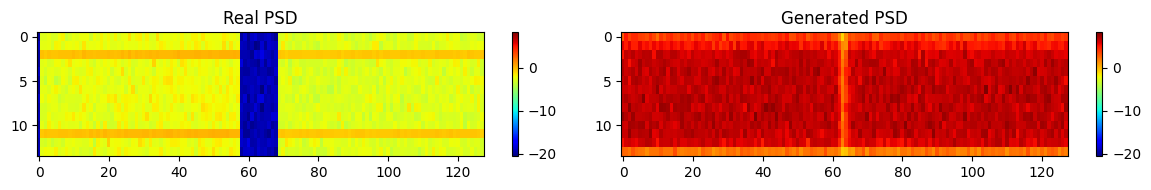

Epoch [100/4000] ebno(db):7.8731 w_d:-0.4625 gp: 9.0679, grad_norm: 0.0478 Loss_D: 8.6054 Loss_G: 9.1292, sse: 72168.0000
Epoch [200/4000] ebno(db):11.3461 w_d:-0.4899 gp: 5.9459, grad_norm: 0.2294 Loss_D: 5.4561 Loss_G: 49.2670, sse: 6922.5166
Epoch [300/4000] ebno(db):9.8746 w_d:-0.4079 gp: 1.1166, grad_norm: 0.6681 Loss_D: 0.7087 Loss_G: 134.3766, sse: 1803.7791
Epoch [400/4000] ebno(db):2.1920 w_d:-0.3548 gp: 0.0058, grad_norm: 1.0045 Loss_D: -0.3490 Loss_G: 215.4969, sse: 565.8631
Epoch [500/4000] ebno(db):5.1455 w_d:-0.4048 gp: 0.0164, grad_norm: 0.9895 Loss_D: -0.3883 Loss_G: 197.4221, sse: 358.2309
0.0017370138 -3.0061761e-07


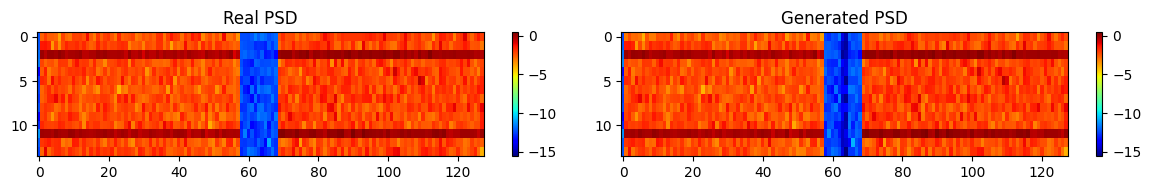

Epoch [600/4000] ebno(db):9.1914 w_d:0.1600 gp: 0.0037, grad_norm: 1.0117 Loss_D: 0.1637 Loss_G: 182.2917, sse: 319.5254
Epoch [700/4000] ebno(db):9.3528 w_d:0.1944 gp: 0.0057, grad_norm: 1.0139 Loss_D: 0.2002 Loss_G: 173.8250, sse: 242.5139
Epoch [800/4000] ebno(db):14.3859 w_d:-0.3649 gp: 0.0680, grad_norm: 1.0631 Loss_D: -0.2968 Loss_G: 168.3792, sse: 194.3734
Epoch [900/4000] ebno(db):3.9854 w_d:-0.0832 gp: 0.0051, grad_norm: 1.0138 Loss_D: -0.0781 Loss_G: 169.2387, sse: 161.5728
Epoch [1000/4000] ebno(db):1.7166 w_d:0.0372 gp: 0.0130, grad_norm: 0.9686 Loss_D: 0.0503 Loss_G: 168.9949, sse: 470.2318
-0.008894862 0.0018977879


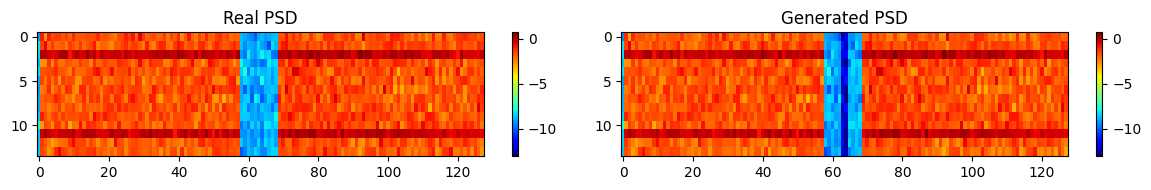

Epoch [1100/4000] ebno(db):0.8785 w_d:-0.3196 gp: 0.0108, grad_norm: 0.9892 Loss_D: -0.3088 Loss_G: 168.0660, sse: 291.3900
Epoch [1200/4000] ebno(db):2.6587 w_d:0.0830 gp: 0.0091, grad_norm: 1.0267 Loss_D: 0.0921 Loss_G: 155.7047, sse: 225.9032
Epoch [1300/4000] ebno(db):10.3744 w_d:-0.1657 gp: 0.0234, grad_norm: 0.9908 Loss_D: -0.1423 Loss_G: 147.7019, sse: 558.5192
Epoch [1400/4000] ebno(db):11.5616 w_d:-0.0484 gp: 0.0275, grad_norm: 0.9741 Loss_D: -0.0209 Loss_G: 145.1366, sse: 667.0239
Epoch [1500/4000] ebno(db):13.7729 w_d:0.3763 gp: 0.0482, grad_norm: 1.0617 Loss_D: 0.4246 Loss_G: 142.1688, sse: 504.7546
-0.008726014 -0.002908996


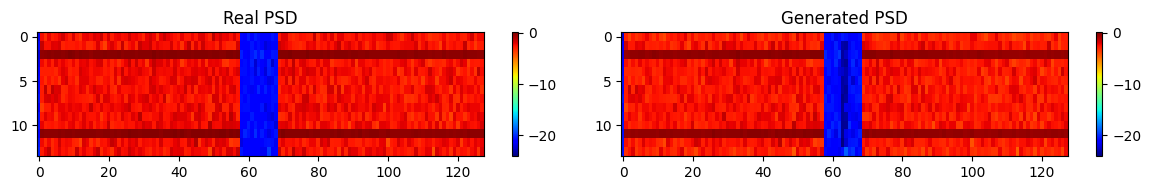

Epoch [1600/4000] ebno(db):12.8888 w_d:0.5331 gp: 0.0292, grad_norm: 1.0403 Loss_D: 0.5623 Loss_G: 138.4412, sse: 928.2960
Epoch [1700/4000] ebno(db):6.1824 w_d:0.6740 gp: 0.0271, grad_norm: 1.0215 Loss_D: 0.7010 Loss_G: 139.5450, sse: 1724.5985
Epoch [1800/4000] ebno(db):9.3280 w_d:0.7062 gp: 0.1280, grad_norm: 0.9091 Loss_D: 0.8342 Loss_G: 133.8076, sse: 4301.9268
Epoch [1900/4000] ebno(db):2.3394 w_d:3.0956 gp: 0.5731, grad_norm: 0.8365 Loss_D: 3.6686 Loss_G: 127.7197, sse: 13281.1875
Epoch [2000/4000] ebno(db):12.2307 w_d:2.3790 gp: 0.8204, grad_norm: 0.7291 Loss_D: 3.1994 Loss_G: 132.7207, sse: 20258.4980
0.01860967 -0.006382303


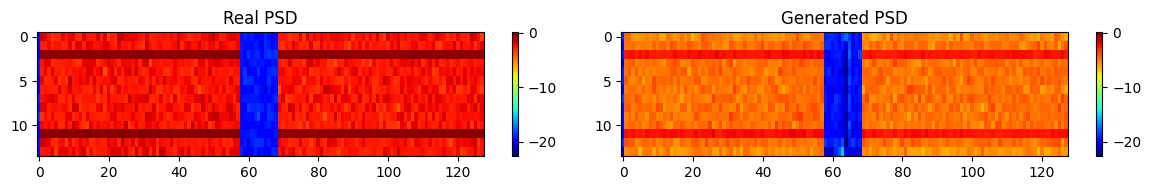

Epoch [2100/4000] ebno(db):5.6600 w_d:5.8779 gp: 1.0219, grad_norm: 0.7050 Loss_D: 6.8998 Loss_G: 110.3599, sse: 38974.4023
Epoch [2200/4000] ebno(db):13.3594 w_d:5.3533 gp: 2.5356, grad_norm: 0.5119 Loss_D: 7.8888 Loss_G: 97.3373, sse: 55272.2539
Epoch [2300/4000] ebno(db):4.4063 w_d:2.3715 gp: 1.2613, grad_norm: 0.6473 Loss_D: 3.6328 Loss_G: 83.2083, sse: 71418.4062
Epoch [2400/4000] ebno(db):10.9978 w_d:0.9433 gp: 3.6415, grad_norm: 0.3990 Loss_D: 4.5848 Loss_G: 78.7295, sse: 139706.1875
Epoch [2500/4000] ebno(db):5.0368 w_d:8.1095 gp: 3.6355, grad_norm: 0.4013 Loss_D: 11.7450 Loss_G: 36.4695, sse: 178064.4062
-0.081604354 -0.00042101598


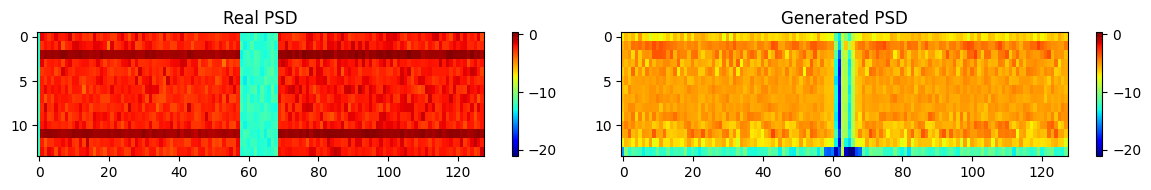

Epoch [2600/4000] ebno(db):13.3455 w_d:6.9064 gp: 5.7523, grad_norm: 0.2433 Loss_D: 12.6587 Loss_G: 19.7359, sse: 317537.1562
Epoch [2700/4000] ebno(db):10.1304 w_d:0.9547 gp: 4.7627, grad_norm: 0.3100 Loss_D: 5.7174 Loss_G: -0.0082, sse: 189361.4844
Epoch [2800/4000] ebno(db):10.3317 w_d:1.4650 gp: 7.3197, grad_norm: 0.1445 Loss_D: 8.7847 Loss_G: -1.2623, sse: 206924.8438
Epoch [2900/4000] ebno(db):7.8099 w_d:2.5926 gp: 7.8116, grad_norm: 0.1163 Loss_D: 10.4043 Loss_G: -1.5850, sse: 301616.9688
Epoch [3000/4000] ebno(db):0.4454 w_d:1.6045 gp: 8.3359, grad_norm: 0.0871 Loss_D: 9.9404 Loss_G: -2.7380, sse: 232110.9375
-0.32058614 0.00054821075


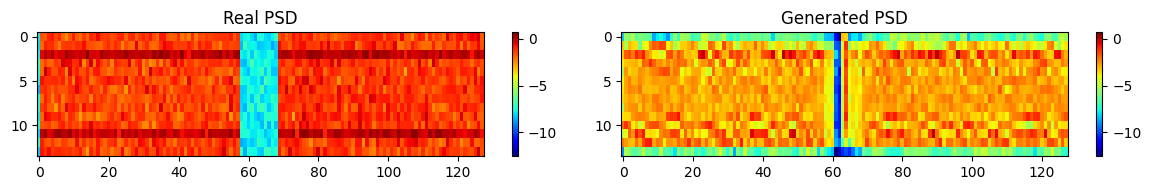

Epoch [3100/4000] ebno(db):5.6593 w_d:1.2072 gp: 8.0913, grad_norm: 0.1005 Loss_D: 9.2985 Loss_G: -0.6368, sse: 146058.9844
Epoch [3200/4000] ebno(db):1.0629 w_d:0.7816 gp: 7.6807, grad_norm: 0.1237 Loss_D: 8.4623 Loss_G: -2.7496, sse: 154312.1562
Epoch [3300/4000] ebno(db):2.8047 w_d:1.4977 gp: 6.0413, grad_norm: 0.2228 Loss_D: 7.5390 Loss_G: -1.8950, sse: 113031.6875
Epoch [3400/4000] ebno(db):13.5793 w_d:0.8724 gp: 6.6467, grad_norm: 0.1853 Loss_D: 7.5192 Loss_G: -0.3554, sse: 88500.2188
Epoch [3500/4000] ebno(db):12.0068 w_d:0.3451 gp: 3.7879, grad_norm: 0.3851 Loss_D: 4.1330 Loss_G: -5.5939, sse: 57867.5547
-0.11188865 -0.0003073161


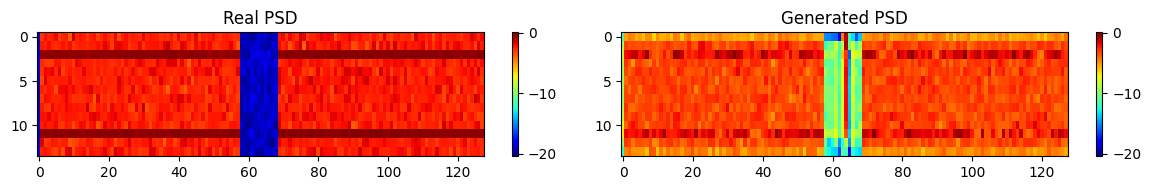

Epoch [3600/4000] ebno(db):9.9567 w_d:0.5803 gp: 2.0536, grad_norm: 0.5490 Loss_D: 2.6339 Loss_G: -14.9084, sse: 40567.3516
Epoch [3700/4000] ebno(db):9.9552 w_d:-0.7094 gp: 1.6199, grad_norm: 0.6027 Loss_D: 0.9105 Loss_G: -8.0778, sse: 32151.7441
Epoch [3800/4000] ebno(db):10.9708 w_d:-0.9486 gp: 0.8427, grad_norm: 0.7235 Loss_D: -0.1059 Loss_G: -0.9033, sse: 21934.0234
Epoch [3900/4000] ebno(db):3.6679 w_d:1.1570 gp: 0.3382, grad_norm: 0.8280 Loss_D: 1.4952 Loss_G: 9.4293, sse: 9018.9805
Epoch [4000/4000] ebno(db):2.2282 w_d:0.1800 gp: 0.4144, grad_norm: 0.8007 Loss_D: 0.5944 Loss_G: 14.1848, sse: 6731.8032
-0.032853868 -0.0009227018


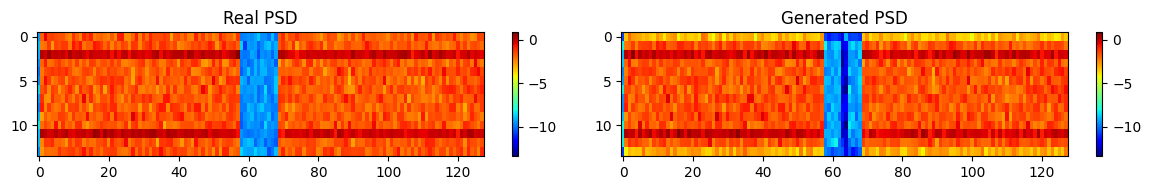

In [ ]:
offset = 0
for i in tqdm(range(offset, epoch+1)):    
    # Sampling a batch of SNRs
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    # ebno_db = tf.constant(10.0, tf.float32)
    
    _, x_rg, _, y_real, h_freq, h_hat_lmmse, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)

    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, y_real, condition_type='yreal') 

    gan_weights_G = WG.get_weights()
    gan_weights_D = WD.get_weights()

    # -----------------------------------------------------------------------     
    list_D.append(loss_D.numpy())
    list_G.append(loss_G.numpy())

    w_dist = tf.reduce_mean(d_real) - tf.reduce_mean(d_fake)  # critic score without GP penalty
    list_W.append(w_dist.numpy())

    if i % 100 == 0: 
        psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
        psd_generated = compute_psd(y_fake)
        sse = tf.reduce_sum(tf.abs(y_real - y_fake)**2)

        print(f"Epoch [{i}/{epoch}] ebno(db):{ebno_db.numpy():.4f} w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, sse: {sse.numpy():.4f}") 
    
    if i % 500 == 0:    
        print(np.mean(y_fake), np.mean(y_real))
        
        psd_real_line = compute_psd_line(y_real)
        psd_generated_line = compute_psd_line(y_fake)
        # plot_psd_line(psd_real_line, psd_generated_line)
        
        # plot_phase_amp_distribution(y_real, y_fake)

        plot_psd(psd_real, psd_generated)

    if i % 1000 == 0: 
        # save GAN weights
        with open(f'gan_weights/real_yreal_v1gan_weights_G_{i}.pkl', 'wb') as f2:
            pickle.dump(gan_weights_G, f2)
        with open(f'gan_weights/real_yreal_v1gan_weights_D_{i}.pkl', 'wb') as f3:
            pickle.dump(gan_weights_D, f3)

In [ ]:
np.savez(f'losses/real_receivedY_v1gan_losses.npz', 
         G=np.array(list_G), 
         D=np.array(list_D), 
         W=np.array(list_W))

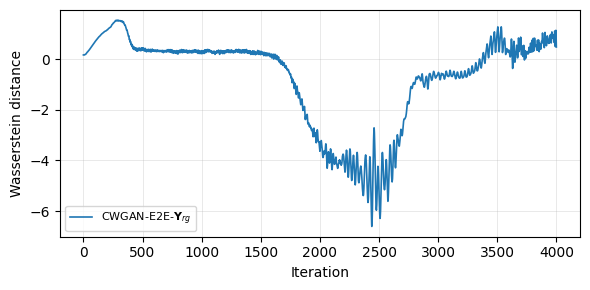

In [ ]:
from scipy.ndimage import uniform_filter1d

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

runs = [
    ('losses/real_pilots_gan_losses.npz',     'CWGAN-E2E-Pilots'),
    ('losses/real_hhat_gan_losses.npz',        'CWGAN-E2E-$\mathbf{H}_{est}$'),
    ('losses/real_receivedY_v1gan_losses.npz', 'CWGAN-E2E-$\mathbf{Y}_{rg}$'),
]

smooth = lambda x: uniform_filter1d(x, size=50)  # adjust window

fig, ax = plt.subplots(figsize=(6, 3))

for run_path, label in runs:
    data = np.load(run_path)
    ax.plot(smooth(data['W']), label=label, linewidth=1.2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Wasserstein distance')
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig('gan_losses_all.png', dpi=300, bbox_inches='tight')

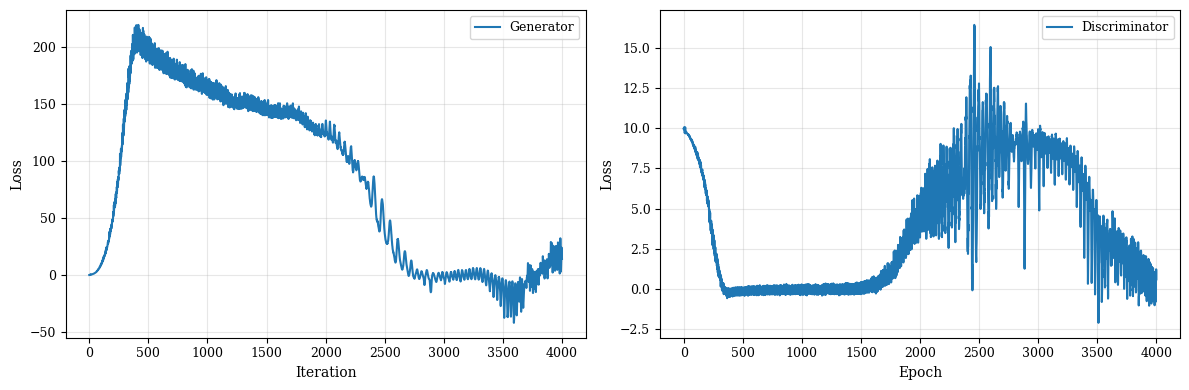

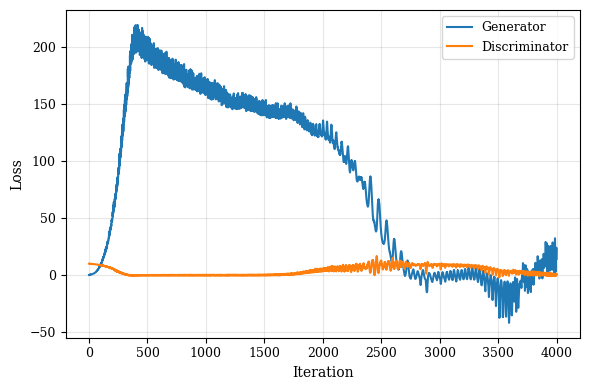

In [ ]:
# IEEE formatting parameters
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 11

G_L = np.asarray([x.item() if hasattr(x, 'item') else float(x) for x in list_G], dtype=np.float32)
D_L = np.asarray([x.item() if hasattr(x, 'item') else float(x) for x in list_D], dtype=np.float32)

# --- Plot 1: side by side ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(G_L, label='Generator')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(D_L, label='Discriminator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pre_real_receivedY_v1gan_losses1.png', dpi=300, bbox_inches='tight')

# --- Plot 2: combined ---
plt.figure(figsize=(6, 4))
plt.plot(G_L, label='Generator', linewidth=1.5)
plt.plot(D_L, label='Discriminator', linewidth=1.5)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pre_real_receivedY_v1gan_losses2.png', dpi=300, bbox_inches='tight')

### Joint E2E training

In [ ]:
with open('gan_weights/real_yreal_v1gan_weights_G_4000.pkl', 'rb') as f:
    g_weights = pickle.load(f)
WG.set_weights(g_weights)
with open('gan_weights/real_yreal_v1gan_weights_D_4000.pkl', 'rb') as f:
    d_weights = pickle.load(f)
WD.set_weights(d_weights)

In [ ]:
offset = 0
grad_check = 1

for i in tqdm(range(offset, num_training_iterations+1)):
    
    # Fine tune
    train_GAN = False # True if (i % 10 == 0) else False # Train GAN every 10 iterations (30000/10=3000 times)

    # Sampling a batch of SNRs
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    if train_GAN:
        _, x_rg, _, y_real, h_freq, h_hat_lmmse, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, y_real, condition_type='yreal') 
        
        gan_weights_G = WG.get_weights()
        gan_weights_D = WD.get_weights()
    
        # -----------------------------------------------------------------------     
        list_D.append(loss_D.numpy())
        list_G.append(loss_G.numpy())

        if i % 2500 == 0: 
            psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
            psd_generated = compute_psd(y_fake)
            sse= tf.reduce_sum(tf.abs(y_real - y_fake)**2)
    
            print(f"Epoch [{i//10}/{num_training_iterations//10}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, sse: {sse.numpy():.4f}") 
    
        if i % 2500 == 0: 
            # print(np.mean(y_fake), np.mean(y_real))
            # psd_real_line = compute_psd_line(y_real)
            # psd_generated_line = compute_psd_line(y_fake)
            # plot_psd_line(psd_real_line, psd_generated_line)
            
            # plot_phase_amp_distribution(y_real, y_fake)
    
            plot_psd(psd_real, psd_generated)

            # save GAN weights
            with open(f'gan_weights/e2e_real_receivedY_v1gan_weights_G_{i}.pkl', 'wb') as f2:
                pickle.dump(gan_weights_G, f2)
            with open(f'gan_weights/e2e_real_receivedY_v1gan_weights_D_{i}.pkl', 'wb') as f3:
                pickle.dump(gan_weights_D, f3)

            np.savez('e2e_receivedY_v1gan_losses.npz', generator=np.asarray(list_G), discriminator=np.asarray(list_D))

    # -----------------------------------------------------------------------
    gan_weights_G = WG.get_weights()
    model._gan_channel.set_weights(gan_weights_G)
    # -----------------------------------------------------------------------
    
    loss_tx, y_gen, y_real, grads_tx = E2E_train__tx_step(ebno_db)
    
    # if grad_check == 1:
    #     print("=" * 10 + "Grads_tx" + "=" * 10)
    #     for i, (grad_tx, weight_tx) in enumerate(zip(grads_tx, model.trainable_weights)):
    #         if grad_tx is None:
    #             print(f"❌ None    : {weight_tx.name} - Shape: {weight_tx.shape}")
    #         else:
    #             print(f"✅ Valid   : {weight_tx.name} - Shape: {weight_tx.shape}")

    loss_rx, grads_rx = E2E_train__rx_step(ebno_db)

    # if grad_check == 1:
    #     print("=" * 10 + "Grads_rx" + "=" * 10)
    #     for j, (grad_rx, weight_rx) in enumerate(zip(grads_rx, model.trainable_weights)):
    #         if grad_rx is None:
    #             print(f"❌ None    : {weight_rx.name} - Shape: {weight_rx.shape}")
    #         else:
    #             print(f"✅ Valid   : {weight_rx.name} - Shape: {weight_rx.shape}")
    # grad_check += 1
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 2500 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

        with open(f'weights_trained/real_v1baseline_receivedY_v1gan_model_weights_SLPmapper_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)
        tf.keras.backend.clear_session()

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/real_v1baseline_receivedY_v1gan_SLPmapper.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 8.8514, Loss_tx: 0.7829, Loss_rx: 0.7969
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.0097e-01 | 1.0000e+00 |      267784 |      534528 |          128 |         128 |         1.4 |reached target block errors
Iteration 2500/30000, Eb/No: 3.5832, Loss_tx: -0.2586, Loss_rx: -0.3022
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.5967e-01 | 1.0000e+00 |       85350 |      534528 |          128 |         128 |         1.2 |reached target block errors
Iteration 5000/30000, Eb/No: 11.6268, Loss_tx: -0.6131, Loss_rx: -0.7572
EbNo [

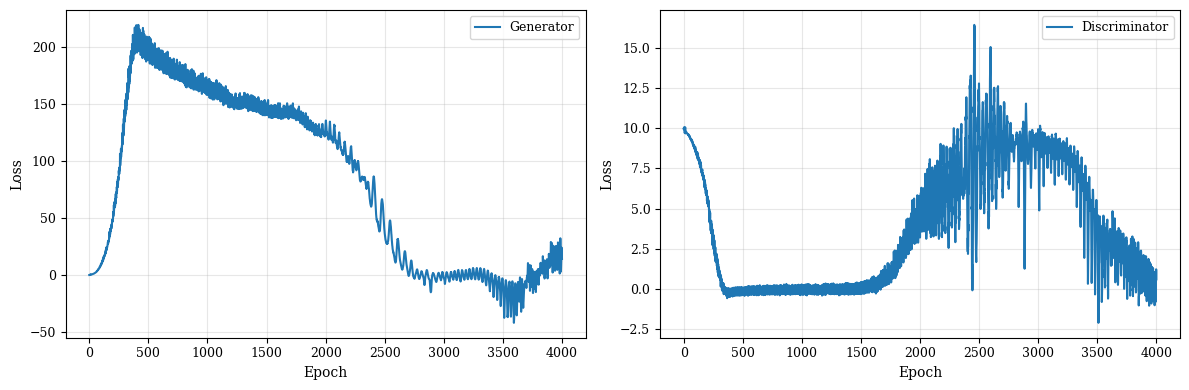

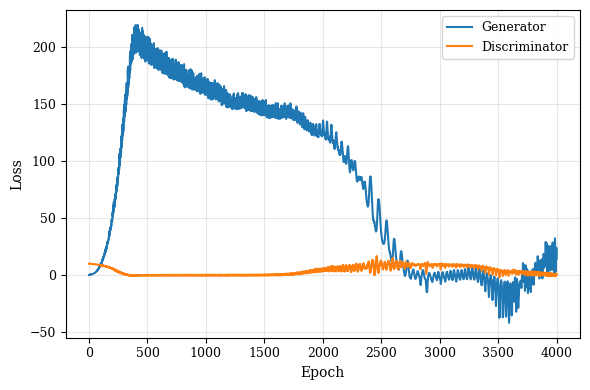

In [ ]:
# IEEE formatting parameters
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 11

G_L = np.asarray(list_G)
D_L = np.asarray(list_D)

np.savez('e2e_hfreq_gan_losses.npz', G_L=G_L, D_L=D_L)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(G_L, label='Generator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(D_L, label='Discriminator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('e2e_real_receivedY_v1gan_losses1.png', dpi=300, bbox_inches='tight')
# ----------------------------------
plt.figure(figsize=(6, 4))
plt.plot(G_L, label='Generator', linewidth=1.5)
plt.plot(D_L, label='Discriminator', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('e2e_real_receivedY_v1gan_losses2.png', dpi=300, bbox_inches='tight')

### Joint training (baseline)

In [ ]:
offset = 0
model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=False)

for i in tqdm(range(offset, num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    weights = model.trainable_weights
    # for w in weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))
     
    if i % 2500 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
        
        eval_model.set_weights(weights)
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/real_v1baseline_model_weights_SLPmapper_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/real_v1baseline_weights_SLPmapper.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 12.1373, Loss: 0.5715
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.9935e-01 | 1.0000e+00 |      266919 |      534528 |          128 |         128 |         1.2 |reached target block errors
Iteration 2500/30000, Eb/No: 14.5689, Loss: -0.6224
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 3.2097e-02 | 6.7969e-01 |       17157 |      534528 |           87 |         128 |         1.2 |reached target block errors
Iteration 5000/30000, Eb/No: 14.5272, Loss: -0.8004
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | 

### Learned Constellation <a class="anchor" id="Constellation"></a>

In [103]:
ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
ebno_db = tf.fill([batch_size], ebno_db)
print(tf.reduce_mean(ebno_db))

tf.Tensor(11.218112, shape=(), dtype=float32)


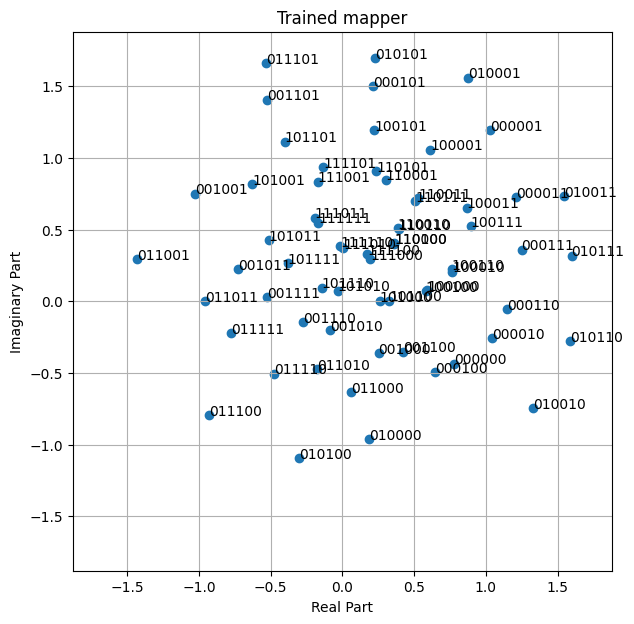

In [105]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
    
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem('mlpSNRMapper-GAN-v1-neural-receiver-v2', training=True, use_fec=True)
pre_build_gan(model._gan_channel)
load_weights(model, "weights_trained/real_receivedY_v1gan_model_weights_MLPmapper_30000.pkl")

# SLP
# constellation_points = tf.complex(model.points_r, model.points_i).numpy()

# others
c = binary_source([batch_size, 1, 1, n])
_, constellation_points = model._mapper(c, ebno_db, training=False)
constellation_points = constellation_points.numpy()  # Take first batch sample

# --------------------------------------------------------
figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")

for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

plt.show()

In [ ]:
# current_config = {
#     'weight_path': 'weights_trained/pilots_model_weights_50000.pkl',
#     'condition_label': r'$\mathbf{x}_p$ and $\mathbf{y}_p$', 
#     'subplot_index': 0,  # 0, 1, or 2
#     'subplot_label': '(a)'  # '(a)', '(b)', or '(c)'
# }

# current_config = {
#     'weight_path': 'weights_trained/hhat_model_weights_50000.pkl',
#     'condition_label': r'$\hat{\mathbf{h}}$', 
#     'subplot_index': 1,
#     'subplot_label': '(b)'
# }

current_config = {
    'weight_path': 'weights_trained/receivedY_model_weights_50000.pkl',
    'condition_label': r'$\mathbf{Y}_{rg}$', 
    'subplot_index': 2,
    'subplot_label': '(c)'
}

# File to store the figure state
data_state_file = 'constellation_data_state.pkl'

def extract_constellation_data(weight_path):
    """Extract constellation data without plotting"""
    model = E2ESystem(training=True, use_fec=True)
    load_weights(model, weight_path)
    constellation = model.constellation
    return constellation.points

# Load existing data or create new storage
if os.path.exists(data_state_file):
    with open(data_state_file, 'rb') as f:
        plot_data = pickle.load(f)
    print(f"Loaded existing data. Completed: {list(plot_data.keys())}")
else:
    plot_data = {}
    print("Created new data storage")

# Extract and store constellation data for current config
subplot_idx = current_config['subplot_index']
if subplot_idx not in plot_data:
    print(f"Extracting data for subplot {subplot_idx}: {current_config['condition_label']}")
    
    constellation_points = extract_constellation_data(current_config['weight_path'])
    
    plot_data[subplot_idx] = {
        'points': constellation_points,
        'condition_label': current_config['condition_label'],
        'subplot_label': current_config['subplot_label']
    }
    
    # Save the data
    with open(data_state_file, 'wb') as f:
        pickle.dump(plot_data, f)
        
    print(f"Saved data for subplot {subplot_idx}")
else:
    print(f"Data for subplot {subplot_idx} already exists")

print(f"Progress: {len(plot_data)}/3 subplots completed")

# Create and save the complete figure when all data is ready
if len(plot_data) == 3:
    print("All data ready! Creating final plot...")
    
    # Set IEEE paper style
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'font.family': 'serif',
        'font.serif': 'Times New Roman'
    })
    
    # Create fresh figure
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    
    # Plot all subplots
    for i in range(3):
        data = plot_data[i]
        points = data['points']
        condition_label = data['condition_label']
        subplot_label = data['subplot_label']
        
        maxval = np.max(np.abs(points)) * 1.05
        axes[i].set_xlim(-maxval, maxval)
        axes[i].set_ylim(-maxval, maxval)
        axes[i].scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].grid(True, which="both", axis="both", alpha=0.3)
        axes[i].set_title(f"{subplot_label} {condition_label}")
        axes[i].set_xlabel("Real Part")
        axes[i].set_ylabel("Imaginary Part")
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)
    
    # Save EPS
    plt.savefig('learned_constellations.eps', format='eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved learned_constellations.eps successfully!")
    
    # Clean up
    if os.path.exists(data_state_file):
        os.remove(data_state_file)
        print("Cleaned up data file")

else:
    # Show preview of current data
    if plot_data:
        plt.figure(figsize=(3, 3))
        latest_data = plot_data[max(plot_data.keys())]
        points = latest_data['points']
        maxval = np.max(np.abs(points)) * 1.05
        plt.xlim(-maxval, maxval)
        plt.ylim(-maxval, maxval)
        plt.scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        plt.title(f"Preview: {latest_data['condition_label']}")
        plt.grid(True, alpha=0.3)
        plt.show()

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [58]:
ebno_dbs_eval = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     1.0) # Step

In [ ]:
# conventional system
conv_model = E2ESystem('qamMapper-baseline-ls-estimation', False, True)
ber,bler  = sim_ber(conv_model, ebno_dbs_eval, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BER['baseline-ls-estimation'] = ber.numpy()
BLER['baseline-ls-estimation'] = bler.numpy()

conv_model = E2ESystem('qamMapper-baseline-perfect-csi', False, True)
ber,bler  = sim_ber(conv_model, ebno_dbs_eval, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BER['baseline-perfect-csi'] = ber.numpy()
BLER['baseline-perfect-csi'] = bler.numpy()

with open('eval_result/coderate12_SISO_baseline_e3000', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.3354e-01 | 1.0000e+00 |      178289 |      534528 |          128 |         128 |         1.7 |reached target block errors
      1.0 | 3.1352e-01 | 1.0000e+00 |      167586 |      534528 |          128 |         128 |         1.5 |reached target block errors
      2.0 | 2.9383e-01 | 1.0000e+00 |      157061 |      534528 |          128 |         128 |         1.5 |reached target block errors
      3.0 | 2.7472e-01 | 1.0000e+00 |      146845 |      534528 |          128 |         128 |         1.5 |reached target block errors
      4.0 | 2.5193e-01 | 1.0000e+00 |      134662 |      534528 |          128 |         128 |         1.5 |reached target block errors
      5.0 | 2.3154e-01 | 1.0000e+00 |      123762 |      534528 |

In [ ]:
eval_model = E2ESystem('slpNoSNRMapper-GAN-v1-neural-receiver-v1', training=False, use_fec=True)
pre_build_gan(eval_model._gan_channel)

with open('eval_weights/real_v1baseline_receivedY_v1gan_SLPmapper.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs_eval, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-trained'] = bler.numpy()
BER['neural-receiver-trained'] = ber.numpy()

with open('eval_result/real_v1baseline_receivedY_v1gan_SLPmapper_model_result', 'wb') as f:
    pickle.dump((ebno_dbs_eval, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8260e-01 | 1.0000e+00 |      151060 |      534528 |          128 |         128 |         1.4 |reached target block errors
      1.0 | 2.5841e-01 | 1.0000e+00 |      138129 |      534528 |          128 |         128 |         1.2 |reached target block errors
      2.0 | 2.3528e-01 | 1.0000e+00 |      125766 |      534528 |          128 |         128 |         1.3 |reached target block errors
      3.0 | 2.1002e-01 | 1.0000e+00 |      112259 |      534528 |          128 |         128 |         1.3 |reached target block errors
      4.0 | 1.8111e-01 | 1.0000e+00 |       96810 |      534528 |          128 |         128 |         1.2 |reached target block errors
      5.0 | 1.2667e-01 | 1.0000e+00 |       67708 |      534528 |

In [ ]:
# 10000 result
cases = [
    (
        'slpNoSNRMapper-GAN-v1-neural-receiver-v1',
        'weights_trained/real_v1baseline_receivedY_v1gan_model_weights_SLPmapper_10000.pkl',
        'eval_result/10000_real_v1baseline_receivedY_v1gan_SLPmapper_model_result',
        False
    ),
    (
        'slpNoSNRMapper-neural-receiver-v1',
        'weights_trained/real_v1baseline_model_weights_SLPmapper_10000.pkl',
        'eval_result/10000_real_v1baseline_SLPmapper_model_result',
        False
    ),
    (
        'mlpSNRMapper-neural-receiver-v1',
        'weights_trained/real_v1baseline_model_weights_MLPmapper_10000.pkl',
        'eval_result/10000_real_v1baseline_MLPmapper_model_result',
        False
    ),
    (
        'mlpSNRMapper-neural-receiver-v2',
        'weights_trained/real_v2baseline_model_weights_MLPmapper_10000.pkl',
        'eval_result/10000_real_v2baseline_MLPmapper_model_result',
        False
    ),
    (
        'resSNRMapper-neural-receiver-v2',
        'weights_trained/real_v2baseline_model_weights_RESmapper_10000.pkl',
        'eval_result/10000_real_v2baseline_RESmapper_model_result',
        False
    ),
    (
        'resSNRMapper-GAN-v1-neural-receiver-v2',
        'weights_trained/real_receivedY_v1gan_model_weights_RESmapper_10000.pkl',
        'eval_result/10000_real_receivedY_v1gan_RESmapper_model_result',
        False
    ),
    (
        'mlpSNRMapper-GAN-v1-neural-receiver-v2',
        'weights_trained/real_receivedY_v1gan_model_weights_MLPmapper_10000.pkl',
        'eval_result/10000_real_receivedY_v1gan_MLPmapper_model_result',
        False
    ),
]

for model_name, weight_file, result_file, use_gan in cases:
    print(f"\n{'='*60}")
    print(f"Evaluating: {result_file}")
    print(f"  Model   : {model_name}")
    print(f"  Weights : {weight_file}")
    print(f"{'='*60}")

    if os.path.exists(result_file):
        print(f"  [SKIP] Inference Result exists: {result_file}")
        continue

    if not os.path.exists(weight_file):
        print(f"  [SKIP] Weight not found: {weight_file}")
        continue

    BLER = {}
    BER = {}

    eval_model = E2ESystem(model_name, training=False, use_fec=True)
    if 'GAN' in model_name:
        pre_build_gan(eval_model._gan_channel)

    with open(weight_file, 'rb') as f:
        weights = pickle.load(f)

    eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
    eval_model.set_weights(weights)

    ber, bler = sim_ber(eval_model, ebno_dbs_eval, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)

    BLER['neural-receiver-trained'] = bler.numpy()
    BER['neural-receiver-trained'] = ber.numpy()

    with open(result_file, 'wb') as f:
        pickle.dump((ebno_dbs_eval, BLER, BER), f)

# Plot

## CWGAN-GP

Baseline:
- 64-QAM + LS-channel-est + LMMSE-equal + std-Demapper
- SLP-mapper (no SNR) + DeepRx
- MLP-mapper-SNR + DeepRx
- MLP-mapper-SNR + v2-NR
- Res-mapper-SNR + v2-NR

GAN (no finetune):
- MLP-mapper-SNR + CWGAN-pilots + v2-NR
- Res-mapper-SNR + CWGAN-pilots + v2-NR
- MLP-mapper-SNR + CWGAN-hhat + v2-NR
- Res-mapper-SNR + CWGAN-hhat + v2-NR
- MLP-mapper-SNR + CWGAN-receivedY + v2-NR
- Res-mapper-SNR + CWGAN-receivedY + v2-NR

/tmp/ipykernel_2913/3253110211.py:97: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((1e-4, 0))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


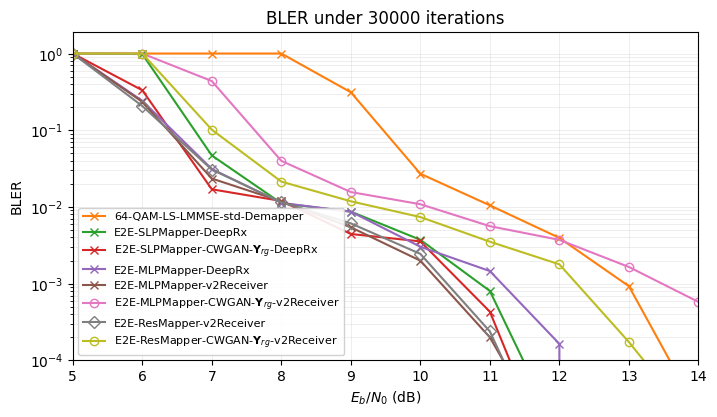

In [79]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

fig = plt.figure(figsize=(7, 4))

with open('eval_result/coderate12_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_base = BER
BLER_base = BLER

# with open('eval_result/MMSEequalization_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_mmse = BER
# BLER_mmse = BLER
with open('eval_result/LS_MMSEequalization_model_result', 'rb') as file: 
        ebno_dbs2, BLER, BER = pickle.load(file)
BER_ls_mmse = BER
BLER_ls_mmse = BLER
# with open('eval_result/LS_NNequalization_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_nn_eq = BER
# BLER_nn_eq = BLER

# ---------------------------------------------
# mapper with no SNR
with open('eval_result/real_v1baseline_SLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_slp = BER
BLER_slp = BLER
with open('eval_result/real_v1baseline_receivedY_v1gan_SLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_slp2 = BER
BLER_slp2 = BLER
with open('eval_result/real_v1baseline_MLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st1 = BER
BLER_st1 = BLER
with open('eval_result/real_v2baseline_MLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st2 = BER
BLER_st2 = BLER
with open('eval_result/real_v2baseline_RESmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st3 = BER
BLER_st3 = BLER


with open('eval_result/real_receivedY_v1gan_RESmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_y = BER
BLER_y = BLER
with open('eval_result/real_receivedY_v1gan_MLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_y2 = BER
BLER_y2 = BLER

# with open('eval_result/10000_real_hhat_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_hh = BER
# BLER_hh = BLER

# with open('eval_result/10000_real_pilots_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_pp = BER
# BLER_pp = BLER
# with open('eval_result/10000_real_pilotsraw_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_pr = BER
# BLER_pr = BLER

# plt.semilogy(ebno_dbs, BLER_base['baseline-perfect-csi'], 'x-', c=f'C6', label=f'64-QAM-CSI-LMMSE-std-Demapper')
plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x-', c=f'C1', label=f'64-QAM-LS-LMMSE-std-Demapper')
# plt.semilogy(ebno_dbs, BLER_mmse['neural-receiver-trained'], 'D-', c=f'C8', markerfacecolor='none', label=f'E2E-NN-Mapper-CSI-LMMSE-NN-Demapper')
# plt.semilogy(ebno_dbs, BLER_ls_mmse['neural-receiver-trained'], 'D-', c=f'C2', markerfacecolor='none', label=f'E2E-LS-LMMSE-NN-Demapper')
# plt.semilogy(ebno_dbs, BLER_nn_eq['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-NN-Mapper-LS-NN-Equalizer-Demapper')

plt.semilogy(ebno_dbs, BLER_slp['neural-receiver-trained'], 'x-', c=f'C2', label=f'E2E-SLPMapper-DeepRx')
plt.semilogy(ebno_dbs, BLER_slp2['neural-receiver-trained'], 'x-', c=f'C3', label=r'E2E-SLPMapper-CWGAN-$\mathbf{Y}_{rg}$-DeepRx')

plt.semilogy(ebno_dbs, BLER_st1['neural-receiver-trained'], 'x-', c=f'C4', label=f'E2E-MLPMapper-DeepRx')
plt.semilogy(ebno_dbs, BLER_st2['neural-receiver-trained'], 'x-', c=f'C5', label=f'E2E-MLPMapper-v2Receiver')
plt.semilogy(ebno_dbs, BLER_y2['neural-receiver-trained'], 'o-', c=f'C6', markerfacecolor='none', label=r'E2E-MLPMapper-CWGAN-$\mathbf{Y}_{rg}$-v2Receiver')

plt.semilogy(ebno_dbs, BLER_st3['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-ResMapper-v2Receiver')

# plt.semilogy(ebno_dbs, BLER_pp['neural-receiver-trained'], 'o-', c=f'C6', markerfacecolor='none', label=r'Res-CWGAN-E2E-Pilots')
# # plt.semilogy(ebno_dbs, BLER_pr['neural-receiver-trained'], 'o-', c=f'C8', markerfacecolor='none', label=r'Res-CWGAN-E2E-Pilots-raw')
# plt.semilogy(ebno_dbs, BLER_hh['neural-receiver-trained'], 'o-', c=f'C7', markerfacecolor='none', label=r'Res-CWGAN-E2E-$\mathbf{H}_{est}$')

plt.semilogy(ebno_dbs, BLER_y['neural-receiver-trained'], 'o-', c=f'C8', markerfacecolor='none', label=r'E2E-ResMapper-CWGAN-$\mathbf{Y}_{rg}$-v2Receiver')


plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BLER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
plt.ylim((1e-4, 0))
plt.xlim((5, 14))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)

plt.title('BLER under 30000 iterations')
plt.tight_layout(pad=0.1)
plt.savefig('plots/real_bler.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/real_bler.eps', format='eps', bbox_inches='tight')
plt.show()

/tmp/ipykernel_2913/2712387109.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((1e-5, 0))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


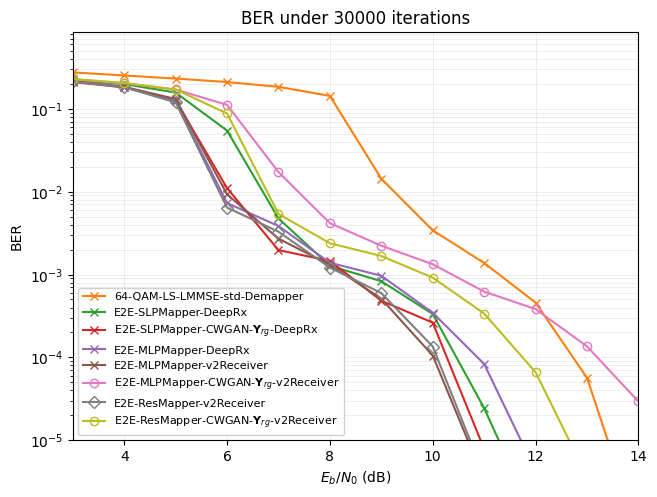

In [90]:
# plt.semilogy(ebno_dbs, BER_base['baseline-perfect-csi'], 'x-', c=f'C6', label=f'64-QAM-CSI-LMMSE-std-Demapper')
plt.semilogy(ebno_dbs, BER_base['baseline-ls-estimation'], 'x-', c=f'C1', label=f'64-QAM-LS-LMMSE-std-Demapper')
# plt.semilogy(ebno_dbs, BER_mmse['neural-receiver-trained'], 'D-', c=f'C8', markerfacecolor='none', label=f'E2E-NN-Mapper-CSI-LMMSE-NN-Demapper')
# plt.semilogy(ebno_dbs, BER_ls_mmse['neural-receiver-trained'], 'D-', c=f'C2', markerfacecolor='none', label=f'E2E-LS-LMMSE-NN-Demapper')
# plt.semilogy(ebno_dbs, BER_nn_eq['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-NN-Mapper-LS-NN-Equalizer-Demapper')

plt.semilogy(ebno_dbs, BER_slp['neural-receiver-trained'], 'x-', c=f'C2', label=f'E2E-SLPMapper-DeepRx')
plt.semilogy(ebno_dbs, BER_slp2['neural-receiver-trained'], 'x-', c=f'C3', label=r'E2E-SLPMapper-CWGAN-$\mathbf{Y}_{rg}$-DeepRx')

plt.semilogy(ebno_dbs, BER_st1['neural-receiver-trained'], 'x-', c=f'C4', label=f'E2E-MLPMapper-DeepRx')
plt.semilogy(ebno_dbs, BER_st2['neural-receiver-trained'], 'x-', c=f'C5', label=f'E2E-MLPMapper-v2Receiver')
plt.semilogy(ebno_dbs, BER_y2['neural-receiver-trained'], 'o-', c=f'C6', markerfacecolor='none', label=r'E2E-MLPMapper-CWGAN-$\mathbf{Y}_{rg}$-v2Receiver')

plt.semilogy(ebno_dbs, BER_st3['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-ResMapper-v2Receiver')

# plt.semilogy(ebno_dbs, BLER_pp['neural-receiver-trained'], 'o-', c=f'C6', markerfacecolor='none', label=r'Res-CWGAN-E2E-Pilots')
# # plt.semilogy(ebno_dbs, BLER_pr['neural-receiver-trained'], 'o-', c=f'C8', markerfacecolor='none', label=r'Res-CWGAN-E2E-Pilots-raw')
# plt.semilogy(ebno_dbs, BLER_hh['neural-receiver-trained'], 'o-', c=f'C7', markerfacecolor='none', label=r'Res-CWGAN-E2E-$\mathbf{H}_{est}$')

plt.semilogy(ebno_dbs, BER_y['neural-receiver-trained'], 'o-', c=f'C8', markerfacecolor='none', label=r'E2E-ResMapper-CWGAN-$\mathbf{Y}_{rg}$-v2Receiver')


plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
plt.ylim((1e-5, 0))
plt.xlim((3, 14))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)

plt.title('BER under 30000 iterations')
plt.tight_layout(pad=0.1)
plt.savefig('plots/real_ber.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/real_ber.eps', format='eps', bbox_inches='tight')
plt.show()

/tmp/ipykernel_2913/246882248.py:67: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((1e-4, 0))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


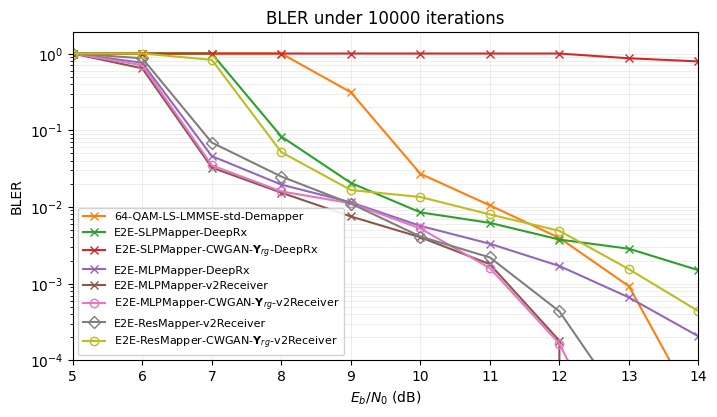

In [92]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

fig = plt.figure(figsize=(7, 4))

with open('eval_result/coderate12_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_base = BER
BLER_base = BLER

with open('eval_result/LS_MMSEequalization_model_result', 'rb') as file: 
        ebno_dbs2, BLER, BER = pickle.load(file)
BER_ls_mmse = BER
BLER_ls_mmse = BLER

# ---------------------------------------------
# mapper with no SNR
with open('eval_result/10000_real_v1baseline_SLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_slp = BER
oBLER_slp = BLER
with open('eval_result/10000_real_v1baseline_receivedY_v1gan_SLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_slp2 = BER
oBLER_slp2 = BLER
with open('eval_result/10000_real_v1baseline_MLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_st1 = BER
oBLER_st1 = BLER
with open('eval_result/10000_real_v2baseline_MLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_st2 = BER
oBLER_st2 = BLER
with open('eval_result/10000_real_v2baseline_RESmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_st3 = BER
oBLER_st3 = BLER


with open('eval_result/10000_real_receivedY_v1gan_RESmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_y = BER
oBLER_y = BLER
with open('eval_result/10000_real_receivedY_v1gan_MLPmapper_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
oBER_y2 = BER
oBLER_y2 = BLER

plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x-', c=f'C1', label=f'64-QAM-LS-LMMSE-std-Demapper')

plt.semilogy(ebno_dbs, oBLER_slp['neural-receiver-trained'], 'x-', c=f'C2', label=f'E2E-SLPMapper-DeepRx')
plt.semilogy(ebno_dbs, oBLER_slp2['neural-receiver-trained'], 'x-', c=f'C3', label=r'E2E-SLPMapper-CWGAN-$\mathbf{Y}_{rg}$-DeepRx')

plt.semilogy(ebno_dbs, oBLER_st1['neural-receiver-trained'], 'x-', c=f'C4', label=f'E2E-MLPMapper-DeepRx')
plt.semilogy(ebno_dbs, oBLER_st2['neural-receiver-trained'], 'x-', c=f'C5', label=f'E2E-MLPMapper-v2Receiver')
plt.semilogy(ebno_dbs, oBLER_y2['neural-receiver-trained'], 'o-', c=f'C6', markerfacecolor='none', label=r'E2E-MLPMapper-CWGAN-$\mathbf{Y}_{rg}$-v2Receiver')

plt.semilogy(ebno_dbs, oBLER_st3['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-ResMapper-v2Receiver')

plt.semilogy(ebno_dbs, oBLER_y['neural-receiver-trained'], 'o-', c=f'C8', markerfacecolor='none', label=r'E2E-ResMapper-CWGAN-$\mathbf{Y}_{rg}$-v2Receiver')


plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BLER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
plt.ylim((1e-4, 0))
plt.xlim((5, 14))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)

plt.title('BLER under 10000 iterations')
plt.tight_layout(pad=0.1)
plt.savefig('plots/real_bler.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/real_bler.eps', format='eps', bbox_inches='tight')
plt.show()

## Res-CWGAN-GP

Res-GAN (no finetune):
- Res-mapper-SNR + Res-CWGAN-pilots + v2-NR
- Res-mapper-SNR + Res-CWGAN-hhat + v2-NR
- Res-mapper-SNR + Res-CWGAN-receivedY + v2-NR

## FiLM

FiLM:
- FiLM-Res-mapper-SNR + Res-CWGAN-pilots + FiLM-v2-NR
- FiLM-Res-mapper-SNR + Res-CWGAN-hhat + FiLM-v2-NR
- FiLM-Res-mapper-SNR + Res-CWGAN-receivedY + FiLM-v2-NR

## Other

### distribution

In [ ]:
def test_trained_gan_100_realizations(model, WG, WD, epoch_to_load=1000):
    # Load trained weights
    with open(f'gan_weights/e2e_receivedY_gan_weights_G_{epoch_to_load}.pkl', 'rb') as f:
        gan_weights_G = pickle.load(f)
    with open(f'gan_weights/e2e_receivedY_gan_weights_D_{epoch_to_load}.pkl', 'rb') as f:
        gan_weights_D = pickle.load(f)
    
    WG.set_weights(gan_weights_G)
    WD.set_weights(gan_weights_D)
    
    real_freq_responses = []
    fake_freq_responses = []
    real_amplitudes_all = []
    fake_amplitudes_all = []
    real_phases_all = []
    fake_phases_all = []
    
    batch_size = 128
    ebno_db = tf.constant(5.0, tf.float32)  # Fixed SNR
    
    # 100 realizations = 100*14*128 =179200 ofdm symbols
    _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    for i in tqdm(range(100)):
        # _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, y_real) # change the condition
        
        # average each realization over batch and OFDM symbols: [batch,ant,ant,14,128] -> [128]
        real_avg = tf.reduce_mean(y_real, axis=[0, 1, 2, 3]).numpy()  # [128]
        fake_avg = tf.reduce_mean(y_fake, axis=[0, 1, 2, 3]).numpy()  # [128]
        
        # frequency responses
        real_freq_responses.append(real_avg)
        fake_freq_responses.append(fake_avg)
        # amplitudes and phases for PDF analysis
        real_amps = np.abs(y_real.numpy()).flatten()
        fake_amps = np.abs(y_fake.numpy()).flatten()
        real_phases = np.angle(y_real.numpy()).flatten()
        fake_phases = np.angle(y_fake.numpy()).flatten()
        
        real_amplitudes_all.extend(real_amps)
        fake_amplitudes_all.extend(fake_amps)
        real_phases_all.extend(real_phases)
        fake_phases_all.extend(fake_phases)
    
    # compute averages
    real_freq_responses = np.array(real_freq_responses)  # [100, 128]
    fake_freq_responses = np.array(fake_freq_responses)  # [100, 128]
    final_real_avg = np.mean(real_freq_responses, axis=0)  # [128]
    final_fake_avg = np.mean(fake_freq_responses, axis=0)  # [128]
    real_amplitudes_all = np.array(real_amplitudes_all)
    fake_amplitudes_all = np.array(fake_amplitudes_all)
    real_phases_all = np.array(real_phases_all)
    fake_phases_all = np.array(fake_phases_all)
    
    # ===== PLOT 1: average mag/phase =====
    freq_axis = np.linspace(-0.5, 0.5, len(final_real_avg))
    
    plt.figure(figsize=(8, 6))
    
    # magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, 20*np.log10(np.abs(final_real_avg)), 'b-', label='Real Channel', linewidth=1)
    plt.plot(freq_axis, 20*np.log10(np.abs(final_fake_avg)), 'ro--', markerfacecolor='none', label='GAN Channel', linewidth=1)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude [dB]')
    plt.legend()
    plt.grid(True)
    # phase plot
    plt.subplot(2, 1, 2)
    plt.plot(freq_axis, np.angle(final_real_avg), 'b-', label='Real Channel', linewidth=1)
    plt.plot(freq_axis, np.angle(final_fake_avg), 'ro--', markerfacecolor='none', label='GAN Channel', linewidth=1)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Phase [rad]')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    # plt.savefig('averaged_frequency_response_100_realizations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== PLOT 2: channel response amplitude distribution =====
    plt.figure(figsize=(6, 4))
    max_amp = max(np.max(real_amplitudes_all), np.max(fake_amplitudes_all))
    bins = np.linspace(0, max_amp, 80)

    plt.hist(real_amplitudes_all, bins=bins, alpha=0.7, density=True, 
             label='Real Samples', color='blue', histtype='step', linewidth=1)
    plt.hist(fake_amplitudes_all, bins=bins, alpha=0.7, density=True, 
             label='Generated Samples', color='red', histtype='step', linewidth=1, linestyle='--')
    
    plt.xlabel('channel response')
    plt.ylabel('Probability Density Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, max_amp)

    plt.tight_layout()
    # plt.savefig('channel_amplitude_distribution.png', dpi=300, bbox_inches='tight')

    plt.figure(figsize=(6, 4))
    max_phase = max(np.max(real_phases_all), np.max(fake_phases_all))
    bins = np.linspace(0, max_phase, 80)

    plt.hist(real_phases_all, bins=bins, alpha=0.7, density=True, 
             label='Real Samples', color='blue', histtype='step', linewidth=1)
    plt.hist(fake_phases_all, bins=bins, alpha=0.7, density=True, 
             label='Generated Samples', color='red', histtype='step', linewidth=1, linestyle='--')
    
    plt.xlabel('channel response')
    plt.ylabel('Probability Density Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, max_phase)
    
    plt.tight_layout()
    # plt.savefig('channel_phase_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
model = E2ESystem(training=True, use_fec=True)

WG = GANGenerator()
WD = GANDiscriminator()

test_trained_gan_100_realizations(model, WG, WD, 30000)

In [ ]:
# amplitude distribution
real_amplitudes_all = []
fake_amplitudes_all = []
batch_size = 128
ebno_db = tf.constant(10.0, tf.float32)

model = E2ESystem(training=True, use_fec=True)
WG = GANGenerator()
WD = GANDiscriminator()

def load_weights(model, model_weights_path, gan_weights_path):
    with open(f'gan_weights/e2e_{gan_weights_path}_gan_weights_G_30000.pkl', 'rb') as f:
        gan_weights_G = pickle.load(f)
    with open(f'gan_weights/e2e_{gan_weights_path}_gan_weights_D_30000.pkl', 'rb') as f:
        gan_weights_D = pickle.load(f)
    
    WG.set_weights(gan_weights_G)
    WD.set_weights(gan_weights_D)

    model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)

# load_weights(model, "weights_trained/pilots_model_weights_15000.pkl", "pilots")
load_weights(model, "weights_trained/hhat_model_weights_30000.pkl", "hhat")
# load_weights(model, "weights_trained/receivedY_model_weights_30000.pkl", "receivedY")

for i in tqdm(range(100)):  # 100 realizations
    # _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    
    # Get generated samples from GAN
    condition = h_hat
    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
    
    # Collect amplitudes
    real_amps = np.abs(y_real.numpy()).flatten()
    fake_amps = np.abs(y_fake.numpy()).flatten()
    
    real_amplitudes_all.extend(real_amps)
    fake_amplitudes_all.extend(fake_amps)

real_amplitudes_all = np.array(real_amplitudes_all)
fake_amplitudes_all = np.array(fake_amplitudes_all)

np.save("plots/cond_amplitudes_real_model_hhat.npy", real_amplitudes_all)
np.save("plots/cond_amplitudes_fake_model_hhat.npy", fake_amplitudes_all)
print(f"Saved {len(real_amplitudes_all)} real amplitude samples")
print(f"Saved {len(fake_amplitudes_all)} generated amplitude samples")

  0%|          | 0/100 [00:00<?, ?it/s]

Saved 22937600 real amplitude samples
Saved 22937600 generated amplitude samples


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


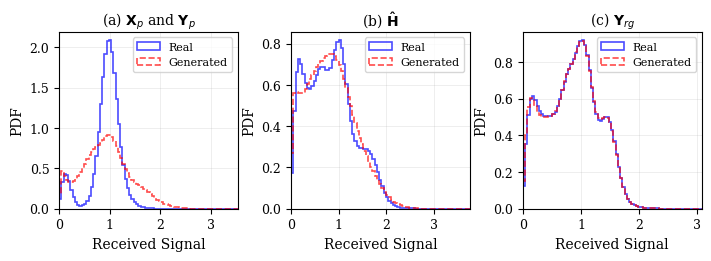

In [139]:
# IEEE formatting parameters
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 11

# Load data
amplitude_files_real = [
    "plots/cond_amplitudes_real_model_pilots.npy",
    "plots/cond_amplitudes_real_model_hhat.npy",
    "plots/cond_amplitudes_real_model_receivedY.npy"
]
amplitude_files_fake = [
    "plots/cond_amplitudes_fake_model_pilots.npy",
    "plots/cond_amplitudes_fake_model_hhat.npy",
    "plots/cond_amplitudes_fake_model_receivedY.npy"
]

titles = ["(a) $\mathbf{X}_p$ and $\mathbf{Y}_p$", "(b) $\mathbf{\hat H}$", "(c) $\mathbf{Y}_{rg}$"]

# IEEE double column width is ~7 inches, single column is ~3.5 inches
# For 3 subplots, use double column width
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))  # IEEE double-column width

for idx, (ax, file_real, file_fake, title) in enumerate(zip(axes, amplitude_files_real, amplitude_files_fake, titles)):
    real_amplitudes = np.load(file_real)
    fake_amplitudes = np.load(file_fake)
    
    max_amp = max(np.max(real_amplitudes), np.max(fake_amplitudes))
    bins = np.linspace(0, max_amp, 80)
    
    ax.hist(real_amplitudes, bins=bins, alpha=0.7, density=True, 
            label='Real', color='blue', histtype='step', linewidth=1.2)
    ax.hist(fake_amplitudes, bins=bins, alpha=0.7, density=True, 
            label='Generated', color='red', histtype='step', linewidth=1.2, linestyle='--')
    
    ax.set_xlabel('Received Signal', fontsize=10)
    ax.set_ylabel('PDF', fontsize=10)
    ax.set_title(title, fontsize=10, pad=5)
    ax.legend(fontsize=8, frameon=True, loc='best')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_xlim(0, max_amp)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout(pad=0.3)
plt.savefig("plots/dist.png", dpi=300, bbox_inches='tight')
plt.savefig('plots/dist.eps', format='eps', bbox_inches='tight')
plt.show()

### Constellation

In [ ]:
# constellation plots
model = E2ESystem(training=True, use_fec=True)

def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)

# load_weights(model, "weights_trained/pilots_model_weights_15000.pkl")
# load_weights(model, "weights_trained/hhat_model_weights_30000.pkl")
# load_weights(model, "weights_trained/receivedY_model_weights_30000.pkl")

# e2e with deeprx noGAN
load_weights(model, "weights_trained/baseline_model_weights_30000.pkl")

constellation_points = model.constellation.points.numpy()

np.save("plots/constellation_model_baseline.npy", constellation_points)
print(f"Saved constellation with {len(constellation_points)} points")

Saved constellation with 64 points


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


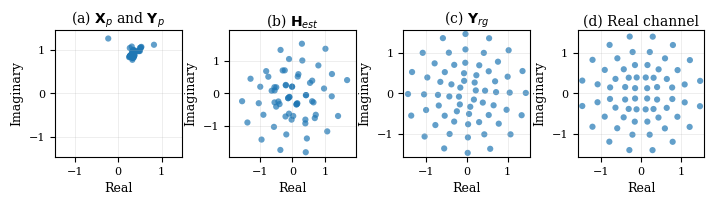

In [ ]:
# IEEE formatting parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Load data
constellation_files = [
    "plots/constellation_model_pilots.npy",
    "plots/constellation_model_hhat.npy",
    "plots/constellation_model_receivedY.npy",
    "plots/constellation_model_baseline.npy"
]

titles = ["(a) $\mathbf{X}_p$ and $\mathbf{Y}_p$", "(b) $\mathbf{H}_{est}$", "(c) $\mathbf{Y}_{rg}$", "(d) Real channel"]

# IEEE double-column width with square subplots
fig, axes = plt.subplots(1, 4, figsize=(7, 2.2))

for idx, (ax, file, title) in enumerate(zip(axes, constellation_files, titles)):
    points = np.load(file)
    maxval = np.max(np.abs(points)) * 1.05
    
    ax.set_xlim(-maxval, maxval)
    ax.set_ylim(-maxval, maxval)
    ax.scatter(np.real(points), np.imag(points), s=20, alpha=0.7, edgecolors='none')
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="both", axis="both", linewidth=0.5, alpha=0.3)
    ax.set_title(title, fontsize=10, pad=3)
    ax.set_xlabel("Real", fontsize=9)
    ax.set_ylabel("Imaginary", fontsize=9)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Reduce number of ticks for clarity
    ax.locator_params(axis='both', nbins=5)

plt.tight_layout(pad=0.2)
plt.savefig("plots/learned_constellations.png", dpi=300, bbox_inches='tight')
plt.savefig('plots/learned_constellations.eps', format='eps', bbox_inches='tight')
plt.show()